In [14]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import datetime, timedelta

In [173]:
# Инициализация данных для обработки
import sqlite3

with sqlite3.connect("./data.db3") as con:
    with open('./sql/select_combinations.sql', 'rt') as f:
        sql_query = f.read()
        data = pd.read_sql(sql_query, con)

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11585 entries, 0 to 11584
Data columns (total 49 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   currency  11585 non-null  object 
 1   t1_dtime  11585 non-null  object 
 2   t1_open   11585 non-null  float64
 3   t1_high   11585 non-null  float64
 4   t1_low    11585 non-null  float64
 5   t1_close  11585 non-null  float64
 6   t1_ma5    11585 non-null  float64
 7   t1_ma10   11585 non-null  float64
 8   t1_ma15   11585 non-null  float64
 9   t2_dtime  11585 non-null  object 
 10  t2_open   11585 non-null  float64
 11  t2_high   11585 non-null  float64
 12  t2_low    11585 non-null  float64
 13  t2_close  11585 non-null  float64
 14  t2_ma5    11585 non-null  float64
 15  t2_ma10   11585 non-null  float64
 16  t2_ma15   11585 non-null  float64
 17  t3_dtime  11585 non-null  object 
 18  t3_open   11585 non-null  float64
 19  t3_high   11585 non-null  float64
 20  t3_low    11585 non-null  fl

In [3]:
data.head()

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_dtime,...,t5_ma10,t5_ma15,t6_dtime,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10,t6_ma15
0,AUD,2001-02-05 12:00:00,0.5507,0.5531,0.5505,0.5516,0.551600,0.551600,0.551600,2001-02-06 00:00:00,...,0.549080,0.549080,2001-02-08 00:00:00,0.5457,0.5464,0.5445,0.5459,0.54794,0.548550,0.548550
1,AUD,2001-02-06 00:00:00,0.5519,0.5527,0.5480,0.5499,0.550750,0.550750,0.550750,2001-02-06 12:00:00,...,0.548550,0.548550,2001-02-08 12:00:00,0.5459,0.5459,0.5415,0.5421,0.54638,0.547629,0.547629
2,AUD,2001-02-06 12:00:00,0.5498,0.5512,0.5473,0.5480,0.549833,0.549833,0.549833,2001-02-07 00:00:00,...,0.547629,0.547629,2001-02-09 00:00:00,0.5420,0.5430,0.5325,0.5368,0.54414,0.546275,0.546275
3,AUD,2001-02-07 00:00:00,0.5479,0.5507,0.5470,0.5494,0.549725,0.549725,0.549725,2001-02-07 12:00:00,...,0.546275,0.546275,2001-02-09 12:00:00,0.5368,0.5370,0.5350,0.5364,0.54154,0.545178,0.545178
4,AUD,2001-02-07 12:00:00,0.5494,0.5499,0.5444,0.5465,0.549080,0.549080,0.549080,2001-02-08 00:00:00,...,0.545178,0.545178,2001-02-10 00:00:00,0.5374,0.5377,0.5342,0.5362,0.53948,0.544280,0.544280


In [4]:
# Проверка пропусков
data.isnull().sum().sum()

np.int64(0)

In [265]:
COMBINATION_LENGTH = 5
TARGET_CANDLE_PREFIX = f't{(COMBINATION_LENGTH + 1)}_'
LAST_CANDLE_PREFIX = f't{(COMBINATION_LENGTH)}_'
LAST_PREV_CANDLE_PREFIX = f't{(COMBINATION_LENGTH) - 1}_'

CLASS_LABEL_KEY = 'class'
OPEN_KEY_SUFFIX = 'open'
HIGH_KEY_SUFFIX = 'high'
LOW_KEY_SUFFIX = 'low'
CLOSE_KEY_SUFFIX = 'close'
MA5_KEY_SUFFIX = 'ma5'
MA10_KEY_SUFFIX = 'ma10'
MA15_KEY_SUFFIX = 'ma15'
NUMERIC_KEYS_SUFFIXES = (OPEN_KEY_SUFFIX, HIGH_KEY_SUFFIX, LOW_KEY_SUFFIX, CLOSE_KEY_SUFFIX, MA5_KEY_SUFFIX, MA10_KEY_SUFFIX, MA15_KEY_SUFFIX)
PRICE_KEYS_SUFFIXES = (OPEN_KEY_SUFFIX, HIGH_KEY_SUFFIX, LOW_KEY_SUFFIX, CLOSE_KEY_SUFFIX)
MA_KEYS_SUFFIXES = (MA5_KEY_SUFFIX, MA10_KEY_SUFFIX, MA15_KEY_SUFFIX)

DATE_KEY_SUFFIX = 'dtime'
DAY_OF_WEEK_SUFFIX = 'dweek'

CURRENCY_KEY_SUFFIX = 'currency'

DIRECTION_KEY_SUFFIX = 'direction'
PART_BODY_KEY_SUFFIX = 'part_body'
PART_HEAD_KEY_SUFFIX = 'head_body'
PART_TAIL_KEY_SUFFIX = 'tail_body'
POSITION_MA5_KEY_SUFFIX = 'ma5_position'
POSITION_MA10_KEY_SUFFIX = 'ma10_position'
POSITION_MA15_KEY_SUFFIX = 'ma15_position'
RATIO_BODY_SIZE_KEY_SUFFIX = 'ratio_body_size'
RATIO_SIZE_KEY_SUFFIX = 'ratio_size'
RATIO_CLOSE_KEY_SUFFIX = 'ratio_close'
POSITION_MA5_HIGH_KEY_SUFFIX = 'ma5_high_position'
POSITION_MA10_HIGH_KEY_SUFFIX = 'ma10_high_position'
POSITION_MA15_HIGH_KEY_SUFFIX = 'ma15_high_position'

PRED_CLASS_LABLE_KEY = 'pred_class'

In [255]:
# Разметка
target_candle_sizes = data[TARGET_CANDLE_PREFIX + HIGH_KEY_SUFFIX] - data[TARGET_CANDLE_PREFIX + LOW_KEY_SUFFIX]
target_candle_body_sizes = np.abs(data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX] - data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX])

last_candle_sizes = data[LAST_CANDLE_PREFIX + HIGH_KEY_SUFFIX] - data[LAST_CANDLE_PREFIX + LOW_KEY_SUFFIX]
last_candle_body_sizes = np.abs(data[LAST_CANDLE_PREFIX + OPEN_KEY_SUFFIX] - data[LAST_CANDLE_PREFIX + CLOSE_KEY_SUFFIX])

last_prev_candle_sizes = data[LAST_PREV_CANDLE_PREFIX + HIGH_KEY_SUFFIX] - data[LAST_PREV_CANDLE_PREFIX + LOW_KEY_SUFFIX]
last_prev_candle_body_sizes = np.abs(data[LAST_PREV_CANDLE_PREFIX + OPEN_KEY_SUFFIX] - data[LAST_PREV_CANDLE_PREFIX + CLOSE_KEY_SUFFIX])

buy_class = (
            (data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] > data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
            # (data[LAST_CANDLE_PREFIX + OPEN_KEY_SUFFIX] > data[LAST_CANDLE_PREFIX + MA5_KEY_SUFFIX]) & 
            # (data[LAST_CANDLE_PREFIX + OPEN_KEY_SUFFIX] > data[LAST_CANDLE_PREFIX + MA10_KEY_SUFFIX]) & 
            # (data[LAST_CANDLE_PREFIX + LOW_KEY_SUFFIX] > data[LAST_CANDLE_PREFIX + MA15_KEY_SUFFIX]) & 
            # (data[LAST_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] > data[LAST_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
            # (data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX] < data[LAST_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
            (last_candle_body_sizes / last_candle_sizes > 0.2) &
            # (last_candle_body_sizes > last_prev_candle_body_sizes * 1.5) &
            # (target_candle_sizes > last_candle_sizes) &
            (target_candle_body_sizes / target_candle_sizes > 0.2)
            )

sell_class = ((data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] < data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
              (data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] < data[LAST_CANDLE_PREFIX + LOW_KEY_SUFFIX]) & 
              (target_candle_body_sizes / target_candle_sizes > 0.7))

data[CLASS_LABEL_KEY] = np.where(buy_class, 1, 
                                 0,)
                                #  np.where(sell_class, 2, 0))
data.value_counts(CLASS_LABEL_KEY)

class
0    50838
1    22888
Name: count, dtype: int64

In [17]:
import mplfinance as mpf

ITEM_INDEXES= range(1, COMBINATION_LENGTH + 1 + 1) # Количество элементов в комбинации + 1 целевой + 1 для невключительной границы

# Транспонирование одного наблюдения в последовательную комбинацию
def transpose_combination(combination_data: pd.Series) -> pd.DataFrame: 
    result = pd.DataFrame(columns=NUMERIC_KEYS_SUFFIXES)
    for i in ITEM_INDEXES:
        result.loc[pd.Timestamp(combination_data.loc[f't{i}_dtime'])] = combination_data.loc[[f't{i}_{key}' for key in NUMERIC_KEYS_SUFFIXES]].values.astype(np.float32)
    return result

def decode_class_label(combination_data: pd.Series) -> tuple[str, str]:
    cls = combination_data.get(CLASS_LABEL_KEY)
    if cls == 1:
        return ('BUY', 'green')
    elif cls == 2:
        return ('SELL', 'red')
    else:
        return ('PASS', 'grey')

# Визуализация комбинации
def print_combination(combination_data: pd.Series, output_folder=None) -> None:
    transposed_combination = transpose_combination(combination_data)
    class_text, class_color = decode_class_label(combination_data)
    fig, axes = mpf.plot(transposed_combination, type='candle', ylabel='', returnfig=True, title=f'Class: {class_text}')

    ax1 = axes[0]

    # Пометка целевой свечи
    ax1.scatter([COMBINATION_LENGTH], transposed_combination[-1:]['open'], color=class_color, s=100)
    
    # Графики MA до последней целевой свечи
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma5'][:-1], color='#FF9D68', label ='ma5')
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma10'][:-1], color='#FF7A92', label ='ma10')
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma15'][:-1], color='#FF4040', label ='ma15')
    
    # График дней недели
    color = 'tab:blue'
    ax2 = ax1.twinx()
    ax2.set_ylabel('Days of week', color=color)
    ax2.plot(transposed_combination.index.day_of_week + 1, marker='o', ls='None', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(0.8, 6.2)
    ax2.grid(False)

    if output_folder is not None:
        filename = f'./{output_folder}/{class_text}_{combination_data['currency']}_{combination_data[TARGET_CANDLE_PREFIX + DATE_KEY_SUFFIX].replace(':','-')}.jpeg' 
        fig.savefig(filename)

6446


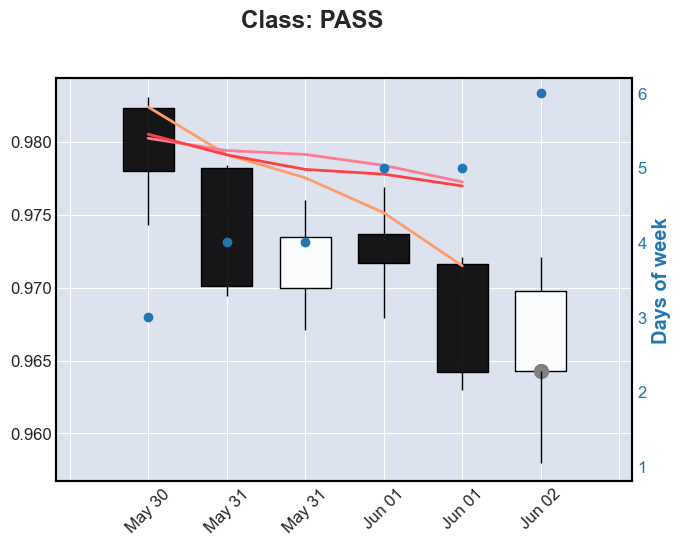

In [6]:
# Печать случайной комбинации
idx = np.random.choice(len(data))
print(idx)
print_combination(data.iloc[idx])

3919


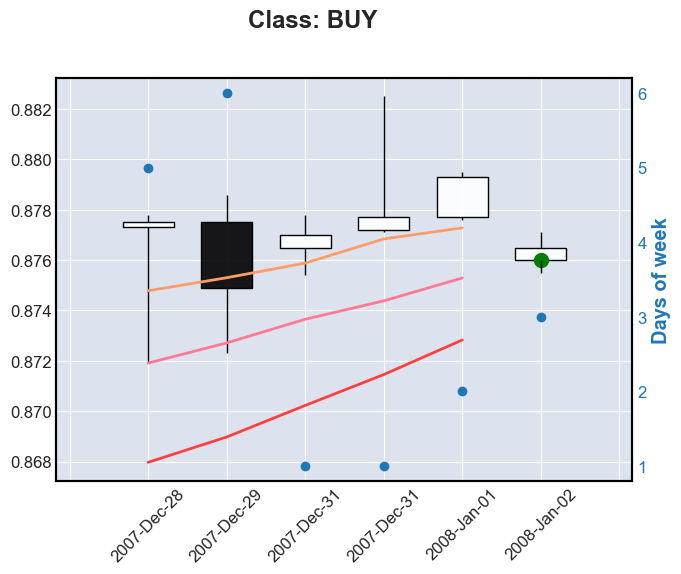

In [151]:
data_true = data[data['class'] == 1]
idx = np.random.choice(data_true.index)
print(idx)
print_combination(data_true.loc[idx])

3621


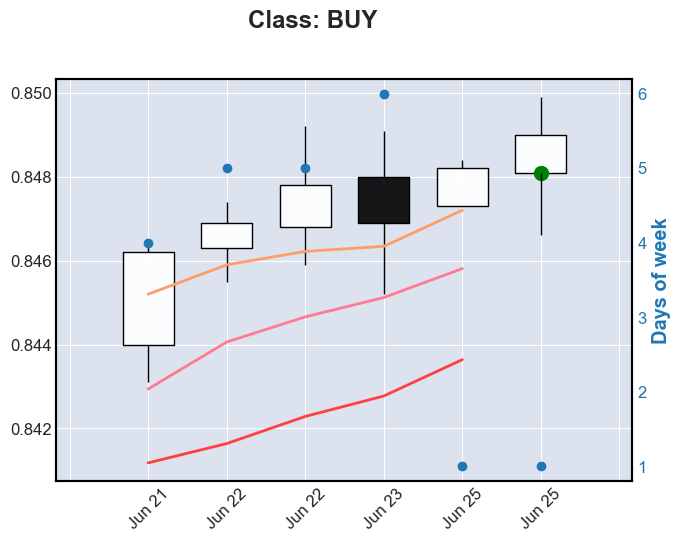

In [142]:
marked_data = data[data['class'] != 0]
idx = np.random.choice(marked_data.index)
print(idx)
print_combination(marked_data.loc[idx])

In [ ]:
for idx in marked_data.index:
    print_combination(marked_data.loc[idx], output_folder='marked_data')

In [256]:
# Предобработка

 # Дискретизация
def part_sampling(p):
    # return np.where(np.isnan(p), 0, np.floor(p * 10)).astype(np.byte)     
    return np.where(np.isnan(p), 0, p)   

processed_data = data.copy()

numeric_columns = [key for key in data.columns 
                   if any([key.endswith(suffix) for suffix in NUMERIC_KEYS_SUFFIXES]) 
                      and (not key.startswith(TARGET_CANDLE_PREFIX) or key == TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX)]

# # Приведение ценовых показаетелей комбинации в масштаб [0,1]
# data_min = data[numeric_columns].min(axis=1)
# data_max = data[numeric_columns].max(axis=1)

# processed_data[numeric_columns] = processed_data[numeric_columns].sub(data_min, axis='rows').divide(data_max - data_min, axis='rows')

# price_columns = [key for key in data.columns 
#                    if any([key.endswith(suffix) for suffix in PRICE_KEYS_SUFFIXES]) 
#                       and (not key.startswith(TARGET_CANDLE_PREFIX) or key == TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX)]

# # Приведение ценовых показаетелей комбинации в масштаб [0,1]
# price_data_min = data[price_columns].min(axis=1)
# price_data_max = data[price_columns].max(axis=1)
# processed_data[price_columns] = processed_data[price_columns].sub(price_data_min, axis='rows').divide(price_data_max - price_data_min, axis='rows')

# ma_columns = [key for key in data.columns 
#                    if any([key.endswith(suffix) for suffix in MA_KEYS_SUFFIXES]) 
#                       and not key.startswith(TARGET_CANDLE_PREFIX)]

# # Приведение ценовых показаетелей комбинации в масштаб [0,1]
# ma_data_min = data[ma_columns].min(axis=1)
# ma_data_max = data[ma_columns].max(axis=1)
# processed_data[ma_columns] = processed_data[ma_columns].sub(ma_data_min, axis='rows').divide(ma_data_max - ma_data_min, axis='rows')

# Выделение дня недели
dtime_columns_fields = [(key, key.removesuffix(DATE_KEY_SUFFIX)) for key in data.columns if key.endswith(DATE_KEY_SUFFIX)]

for dtime_key, prefix in dtime_columns_fields:
    processed_data[prefix + DAY_OF_WEEK_SUFFIX] = processed_data[dtime_key].map(lambda t: datetime.fromisoformat(t).weekday())

for i in (range(1, COMBINATION_LENGTH + 1)):
    prefix = f't{i}_'
    
    data_open = data[prefix + OPEN_KEY_SUFFIX]
    data_high = data[prefix + HIGH_KEY_SUFFIX]
    data_low = data[prefix + LOW_KEY_SUFFIX]
    data_close = data[prefix + CLOSE_KEY_SUFFIX]
    data_ma5 = data[prefix + MA5_KEY_SUFFIX]
    data_ma10 = data[prefix + MA10_KEY_SUFFIX]
    data_ma15 = data[prefix + MA15_KEY_SUFFIX]

    data_size = data_high - data_low
    data_body_size = np.abs(data_close - data_open)

    if i > 1:
        prev_prefix = f't{i-1}_'

        prev_data_size = data[prev_prefix + HIGH_KEY_SUFFIX] - data[prev_prefix + LOW_KEY_SUFFIX]
        ratio_size = prev_data_size / data_size
        ratio_size = np.where((np.isnan(ratio_size) | np.isinf(ratio_size)), 0, ratio_size)
        processed_data[prefix + RATIO_SIZE_KEY_SUFFIX] = ratio_size

        prev_data_body_size = np.abs(data[prev_prefix + OPEN_KEY_SUFFIX] - data[prev_prefix + CLOSE_KEY_SUFFIX])
        ratio_body_size = prev_data_body_size / data_body_size
        ratio_body_size = np.where((np.isnan(ratio_body_size) | np.isinf(ratio_body_size)), 0, ratio_body_size)
        processed_data[prefix + RATIO_BODY_SIZE_KEY_SUFFIX] = ratio_body_size

        prev_close = data[prev_prefix + CLOSE_KEY_SUFFIX]
        processed_data[prefix + RATIO_CLOSE_KEY_SUFFIX] =  data_close / prev_close
        
        

    # Раскраска свечи
    processed_data[prefix + DIRECTION_KEY_SUFFIX] = (data_close > data_open).astype(np.byte)

    processed_data[prefix + PART_BODY_KEY_SUFFIX] = part_sampling(data_body_size / data_size)
    processed_data[prefix + PART_HEAD_KEY_SUFFIX] = part_sampling((data_high - np.max([data_close, data_open], axis=0)) / data_size)
    processed_data[prefix + PART_TAIL_KEY_SUFFIX] = part_sampling((np.min([data_close, data_open], axis=0) - data_low) / data_size)

    # Относительное позиционирование
    processed_data[prefix + POSITION_MA5_KEY_SUFFIX] = np.where(data_ma5 < data_low, 0,
                                                                np.where(data_ma5 < np.min([data_close, data_open], axis=0), 1,
                                                                         np.where(data_ma5 < np.max([data_close, data_open], axis=0), 2,
                                                                                  np.where(data_ma5 < data_high, 3, 4))))
    
    processed_data[prefix + POSITION_MA10_KEY_SUFFIX] = np.where(data_ma10 < data_low, 0,
                                                            np.where(data_ma10 < np.min([data_close, data_open], axis=0), 1,
                                                                        np.where(data_ma10 < np.max([data_close, data_open], axis=0), 2,
                                                                                np.where(data_ma10 < data_high, 3, 4))))
    
    processed_data[prefix + POSITION_MA15_KEY_SUFFIX] = np.where(data_ma15 < data_low, 0,
                                                            np.where(data_ma15 < np.min([data_close, data_open], axis=0), 1,
                                                                        np.where(data_ma15 < np.max([data_close, data_open], axis=0), 2,
                                                                                np.where(data_ma15 < data_high, 3, 4))))

    # processed_data[prefix + POSITION_MA5_KEY_SUFFIX] = data_ma5 - data_low
    # processed_data[prefix + POSITION_MA10_KEY_SUFFIX] = data_ma10 - data_low
    # processed_data[prefix + POSITION_MA15_KEY_SUFFIX] = data_ma15 - data_low
    
    # processed_data[prefix + POSITION_MA5_HIGH_KEY_SUFFIX] = data_ma5 - data_high
    # processed_data[prefix + POSITION_MA10_HIGH_KEY_SUFFIX] = data_ma10 - data_high
    # processed_data[prefix + POSITION_MA15_HIGH_KEY_SUFFIX] = data_ma15 - data_high



In [ ]:
# Удаление лишних столбцов
dtime_columns = [column[0] for column in dtime_columns_fields]
target_candle_columns = [column for column in processed_data.columns if column.startswith(TARGET_CANDLE_PREFIX) and column != TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]
droped_columns = [CURRENCY_KEY_SUFFIX] + dtime_columns + target_candle_columns + numeric_columns

processed_data = processed_data.drop(droped_columns, axis=1)

In [258]:
# Не понедельники
processed_data = processed_data[processed_data[LAST_CANDLE_PREFIX + DAY_OF_WEEK_SUFFIX] != 5]

In [226]:

# pd.set_option('display.max_rows', 100) 
# processed_data.iloc[idx]

processed_data.head()

,class,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_direction,t1_part_body,t1_head_body,t1_tail_body,...,t5_ratio_size,t5_ratio_body_size,t5_ratio_close,t5_direction,t5_part_body,t5_head_body,t5_tail_body,t5_ma5_position,t5_ma10_position,t5_ma15_position
0,1,0,1,1,2,2,1,0.346154,0.576923,0.076923,...,0.672727,0.517241,0.994722,0,0.527273,0.090909,0.381818,2,2,2
1,0,1,1,2,2,3,0,0.425532,0.170213,0.404255,...,2.894737,14.500000,0.998902,1,0.105263,0.263158,0.631579,4,4,4
2,0,1,2,2,3,3,0,0.461538,0.358974,0.179487,...,0.431818,0.052632,0.993039,0,0.863636,0.000000,0.136364,4,4,4
3,0,2,2,3,3,4,1,0.405405,0.351351,0.243243,...,0.419048,0.730769,0.990223,0,0.495238,0.095238,0.409524,4,4,4
4,0,2,3,3,4,4,0,0.527273,0.090909,0.381818,...,5.250000,13.000000,0.999255,0,0.200000,0.100000,0.700000,4,4,4


In [189]:
processed_data.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t5_ratio_size,t5_ratio_body_size,t5_ratio_close,t5_direction,t5_part_body,t5_head_body,t5_tail_body,t5_ma5_position,t5_ma10_position,t5_ma15_position
count,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,...,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000
mean,0.497561,0.728421,0.267610,0.500486,0.500259,0.497166,0.492704,0.499732,0.729186,0.270498,...,1.302134,3.093989,1.000003,0.500122,0.439105,0.278125,0.282296,1.986667,1.974622,1.968057
std,0.308070,0.261441,0.262517,0.248884,0.330584,0.327018,0.443674,0.248702,0.221480,0.222657,...,1.263740,8.021450,0.004301,0.500003,0.249775,0.195713,0.197722,1.341918,1.636169,1.729672
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.863101,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.213592,0.510000,0.000000,0.291667,0.216408,0.207148,0.000000,0.291139,0.562056,0.067901,...,0.641975,0.333333,0.997923,0.000000,0.230769,0.120812,0.123077,1.000000,0.000000,0.000000
50%,0.494382,0.781457,0.206897,0.500000,0.499114,0.491487,0.474239,0.497468,0.760254,0.237838,...,1.000000,0.940000,1.000000,1.000000,0.440000,0.241379,0.246377,2.000000,2.000000,2.000000
75%,0.780702,1.000000,0.487805,0.710373,0.785180,0.789474,1.000000,0.708950,0.930806,0.438776,...,1.521127,2.538462,1.002117,1.000000,0.640625,0.404255,0.410714,3.000000,4.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.982143,...,45.000000,221.250000,1.086242,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000


In [227]:
processed_data.columns

Index(['class', 't1_dweek', 't2_dweek', 't3_dweek', 't4_dweek', 't5_dweek',
       't1_direction', 't1_part_body', 't1_head_body', 't1_tail_body',
       't1_ma5_position', 't1_ma10_position', 't1_ma15_position',
       't2_ratio_size', 't2_ratio_body_size', 't2_ratio_close', 't2_direction',
       't2_part_body', 't2_head_body', 't2_tail_body', 't2_ma5_position',
       't2_ma10_position', 't2_ma15_position', 't3_ratio_size',
       't3_ratio_body_size', 't3_ratio_close', 't3_direction', 't3_part_body',
       't3_head_body', 't3_tail_body', 't3_ma5_position', 't3_ma10_position',
       't3_ma15_position', 't4_ratio_size', 't4_ratio_body_size',
       't4_ratio_close', 't4_direction', 't4_part_body', 't4_head_body',
       't4_tail_body', 't4_ma5_position', 't4_ma10_position',
       't4_ma15_position', 't5_ratio_size', 't5_ratio_body_size',
       't5_ratio_close', 't5_direction', 't5_part_body', 't5_head_body',
       't5_tail_body', 't5_ma5_position', 't5_ma10_position',
       't5

In [57]:
processed_data.isnull().sum().sum()

np.int64(0)

In [259]:
# Моделирование
from sklearn.metrics import precision_score, classification_report
from sklearn.model_selection import train_test_split

# Разделение на множества данных
X_train, X_test, y_train, y_test = train_test_split(
    processed_data.drop([CLASS_LABEL_KEY], axis=1), processed_data[CLASS_LABEL_KEY], test_size=0.3, random_state=5, shuffle=True, stratify=processed_data[CLASS_LABEL_KEY]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=5, stratify=y_test
)

print(f'Тренировочный набор: {y_train.value_counts()}')
print(f'Валидационный набор: {y_val.value_counts()}')
print(f'Тестовый набор: {y_test.value_counts()}')

Тренировочный набор: class
0    32403
1    14523
Name: count, dtype: int64
Валидационный набор: class
0    6944
1    3112
Name: count, dtype: int64
Тестовый набор: class
0    6944
1    3112
Name: count, dtype: int64


# NL

In [178]:
import torch
import torch.nn as nn
import torch.optim as optim

In [179]:
from sklearn.preprocessing import StandardScaler

# Нормализация
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [180]:
# Конвертация в тензоры PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train.to_numpy()).view(-1, 1)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val.to_numpy()).view(-1, 1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test.to_numpy()).view(-1, 1)

In [181]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [182]:
# Итератор с батчеризацией
class BatchLoader():
    def __init__(self, X, y, batch_size):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.last_idx = 0
        self.dataset_size = len(X)

    def reset(self):
        self.last_idx = 0

    def __next__(self):
        if (self.last_idx == self.dataset_size):
            raise StopIteration
        
        start_idx = self.last_idx
        end_idx = start_idx + self.batch_size if start_idx + self.batch_size < self.dataset_size else self.dataset_size

        self.last_idx = end_idx
        return self.X[start_idx:end_idx], self.y[start_idx:end_idx]
    
    def __iter__(self):
        return self

    def __len__(self):
        return math.ceil(self.dataset_size / self.batch_size)

In [183]:
# Функция для обучения модели
def train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs):
    criterion = nn.BCEWithLogitsLoss()

    train_loader = BatchLoader(X_train, y_train, batch_size)
    total_step = len(train_loader)

    # История потерь
    train_losses = []
    val_losses = []
    last_epoch = 0

    for epoch in range(num_epochs):
        need_log_epoch = epoch % (num_epochs // 5) == 0

        if need_log_epoch:
            print(f"Start of {epoch+1} Epoch:")

        train_batch_losses = []
        for i, (X, y) in enumerate(train_loader):  
            model.train()

            # Move tensors to the configured device
            X = X.to(device)
            y = y.to(device)
            
            # Forward pass
            outputs = model(X)
            loss = criterion(outputs, y)

            # Потери по пакету    
            train_batch_losses.append(loss.item())
            
            # Backprpagation and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            need_log_batch = (i % (total_step // 5)) == 0
            if need_log_epoch and need_log_batch:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                    .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))

        # Потеря эпохи как средняя потеря по пакету    
        train_losses.append(np.array(train_batch_losses).mean())

        # Расчет потери на валидационной выборке
        val_batch_losses = []
        with torch.no_grad():
            model.eval()
            val_loader = BatchLoader(X_val, y_val, batch_size)
            for (X, y) in val_loader:
                X = X.to(device)
                y = y.to(device)
                outputs = model(X)

                loss = criterion(outputs, y)
                # Потери по пакету    
                val_batch_losses.append(loss.item())
            
            # Потеря эпохи как средняя потеря по пакету   
            val_losses.append(np.array(val_batch_losses).mean())

        val_loader.reset()    
        train_loader.reset()
        last_epoch = epoch

        # Ранняя остановка в случае отсутствия прогресса обучения
        if epoch > num_patience_epochs:
            start_epoch = train_losses[-num_patience_epochs]
            checked_epochs = train_losses[-num_patience_epochs + 1:]
            if all([start_epoch  < checked_epoch for checked_epoch in checked_epochs]):
                break
    
    return (last_epoch + 1, train_losses, val_losses)

In [184]:
# Визуализация потерь на обучающей и валидационной выборке
def print_losses(learning_epochs, train_losses, val_losses, title):
    epochs = range(0, learning_epochs)
    ax = plt.figure(figsize=(10,5))
    plt.title(f'Потери в процессе обучения\n{title}\nЭпохи [{learning_epochs}]')
    plt.plot(epochs, train_losses, label='Train')
    plt.plot(epochs, val_losses, label='Val')
    plt.legend()

In [185]:
# Проверка модели
def test_model(model, X_test, y_test, bath_size, title):
    test_loader = BatchLoader(X_test, y_test, bath_size)
    y_pred = torch.FloatTensor().to(device)

    with torch.no_grad():
        model.eval()
        for (X, _) in test_loader:
            X = X.to(device)
            outputs = model(X)
            outputs = torch.round(torch.sigmoid(outputs))
            y_pred = torch.cat([y_pred, outputs], dim=0)

    y_pred_np = y_pred.cpu().view(-1).numpy()
    y_test_np = y_test.view(-1).numpy()
    

    score = f'Precision: {precision_score(y_true=y_test_np, y_pred=y_pred_np):.6f}'

    print(score)

## FNN

In [190]:
class Config:
    LEARNING_RATE = 0.001

    INPUT_SIZE = 88
    HIDDEN_SIZE = 200
    OUTPUT_SIZE = 1

In [186]:
# Модель для классификации
class FunctionClassifier(nn.Module):
    def __init__(self, input_size=2, hidden_size=10, output_size=1):
        super(FunctionClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

Start of 1 Epoch:
Epoch [1/200], Step [1/202], Loss: 0.6470
Epoch [1/200], Step [41/202], Loss: 0.2581
Epoch [1/200], Step [81/202], Loss: 0.1741
Epoch [1/200], Step [121/202], Loss: 0.1940
Epoch [1/200], Step [161/202], Loss: 0.1319
Epoch [1/200], Step [201/202], Loss: 0.1209
Start of 41 Epoch:
Epoch [41/200], Step [1/202], Loss: 0.0899
Epoch [41/200], Step [41/202], Loss: 0.0846
Epoch [41/200], Step [81/202], Loss: 0.1109
Epoch [41/200], Step [121/202], Loss: 0.0911
Epoch [41/200], Step [161/202], Loss: 0.0642
Epoch [41/200], Step [201/202], Loss: 0.0652
Start of 81 Epoch:
Epoch [81/200], Step [1/202], Loss: 0.0522
Epoch [81/200], Step [41/202], Loss: 0.0531
Epoch [81/200], Step [81/202], Loss: 0.0702
Epoch [81/200], Step [121/202], Loss: 0.0441
Epoch [81/200], Step [161/202], Loss: 0.0254
Epoch [81/200], Step [201/202], Loss: 0.0459
Start of 121 Epoch:
Epoch [121/200], Step [1/202], Loss: 0.0235
Epoch [121/200], Step [41/202], Loss: 0.0280
Epoch [121/200], Step [81/202], Loss: 0.037

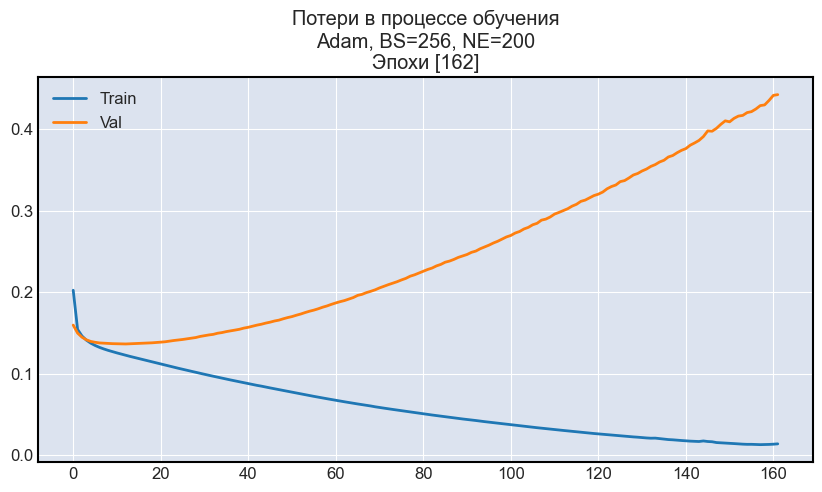

In [191]:
batch_size = 256
num_epochs = 200
num_patience_epochs = 5

model = FunctionClassifier(Config.INPUT_SIZE, Config.HIDDEN_SIZE, Config.OUTPUT_SIZE)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)  

# Обучение
(learning_epochs, train_losses, val_losses) = train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs)

# Проверка и визуализация
model_description = f'Adam, BS={batch_size}, NE={num_epochs}'
print_losses(learning_epochs, train_losses, val_losses, title=model_description)
test_model(model, X_val, y_val, batch_size, title="Функция\n" + model_description)

In [192]:
test_model(model, X_test, y_test, batch_size, title="Функция\n" + model_description)

Precision: 0.474251


##  CNN

In [196]:
class CNNModel(nn.Module):
    def __init__(self, num_features, num_classes=3):
        super(CNNModel, self).__init__()
        
        # Первый слой свертки: извлекает локальные паттерны (фигуры свечей)
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=64, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        
        # Второй слой свертки: извлекает более глобальные зависимости (последовательность паттернов)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        
        # Pooling: уменьшаем размерность, оставляя только самые важные признаки
        self.pool = nn.AdaptiveAvgPool1d(1) # Сжимает последовательность до размера 1
        
        # Полносвязный слой для классификации
        self.fc = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = x.view(-1, 88, 1)
        # x shape: (batch_size, num_features, seq_length)
        
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.conv2(x)
        x = self.relu2(x)
        
        x = self.conv3(x)
        x = self.relu3(x)
        
        # Global Average Pooling
        x = self.pool(x) # shape: (batch, 64, 1)
        x = torch.flatten(x, 1) # shape: (batch, 64)
        
        x = self.fc(x)
        return x

In [194]:
from torchsummary import summary

cnn_model = CNNModel(num_features=Config.INPUT_SIZE, num_classes=Config.OUTPUT_SIZE)
print(cnn_model)

# example_batch = next(enumerate(train_loader))[1][0]
# print('Batch example size: ', example_batch.shape)

# print('Summary:')
# example_x = example_batch[0]
# summary(cnn_model, example_x.shape, device='cpu')

CNNModel(
  (conv1): Conv1d(88, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (conv3): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu3): ReLU()
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Start of 1 Epoch:
Epoch [1/200], Step [1/202], Loss: 0.6808
Epoch [1/200], Step [41/202], Loss: 0.2606
Epoch [1/200], Step [81/202], Loss: 0.1520
Epoch [1/200], Step [121/202], Loss: 0.1714
Epoch [1/200], Step [161/202], Loss: 0.1259
Epoch [1/200], Step [201/202], Loss: 0.1069
Start of 41 Epoch:
Epoch [41/200], Step [1/202], Loss: 0.1139
Epoch [41/200], Step [41/202], Loss: 0.1308
Epoch [41/200], Step [81/202], Loss: 0.1079
Epoch [41/200], Step [121/202], Loss: 0.1127
Epoch [41/200], Step [161/202], Loss: 0.0833
Epoch [41/200], Step [201/202], Loss: 0.0915
Precision: 0.443609


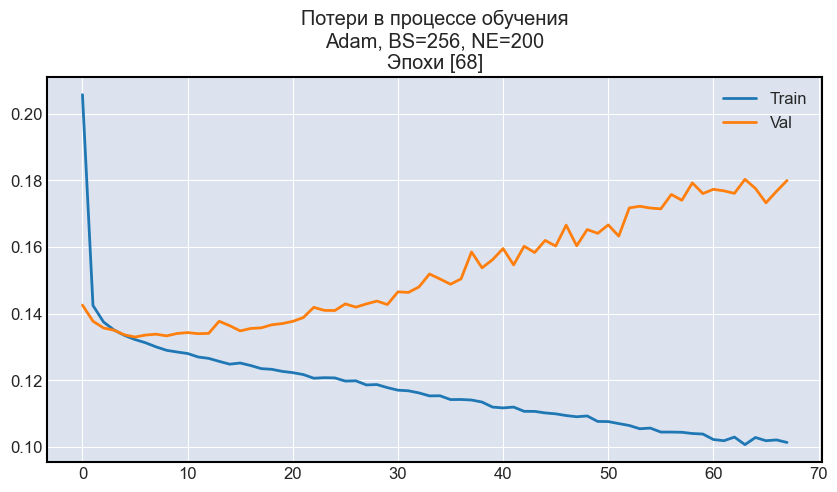

In [197]:
batch_size = 256
num_epochs = 200
num_patience_epochs = 5

model = CNNModel(num_features=Config.INPUT_SIZE, num_classes=Config.OUTPUT_SIZE)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)  

# Обучение
(learning_epochs, train_losses, val_losses) = train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs)

# Проверка и визуализация
model_description = f'Adam, BS={batch_size}, NE={num_epochs}'
print_losses(learning_epochs, train_losses, val_losses, title=model_description)
test_model(model, X_val, y_val, batch_size, title="Функция\n" + model_description)

In [198]:
test_model(model, X_test, y_test, batch_size, title="Функция\n" + model_description)

Precision: 0.458599


# ML

In [229]:
def get_weight(feature: str):
    if feature.startswith(f't{COMBINATION_LENGTH + 1}'):
        return 2
    elif feature.startswith(f't{COMBINATION_LENGTH}'):
        return 2
    elif feature.startswith(f't{COMBINATION_LENGTH - 1}'):
        return 1.5
    elif feature.startswith('t1'):
        return 0.5
    else:
        return 1
    return 1
    
feature_weights = {feature: get_weight(feature) for feature in processed_data.columns}
feature_weights

{'class': 1,
 't1_dweek': 0.5,
 't2_dweek': 1,
 't3_dweek': 1,
 't4_dweek': 1.5,
 't5_dweek': 2,
 't1_direction': 0.5,
 't1_part_body': 0.5,
 't1_head_body': 0.5,
 't1_tail_body': 0.5,
 't1_ma5_position': 0.5,
 't1_ma10_position': 0.5,
 't1_ma15_position': 0.5,
 't2_ratio_size': 1,
 't2_ratio_body_size': 1,
 't2_ratio_close': 1,
 't2_direction': 1,
 't2_part_body': 1,
 't2_head_body': 1,
 't2_tail_body': 1,
 't2_ma5_position': 1,
 't2_ma10_position': 1,
 't2_ma15_position': 1,
 't3_ratio_size': 1,
 't3_ratio_body_size': 1,
 't3_ratio_close': 1,
 't3_direction': 1,
 't3_part_body': 1,
 't3_head_body': 1,
 't3_tail_body': 1,
 't3_ma5_position': 1,
 't3_ma10_position': 1,
 't3_ma15_position': 1,
 't4_ratio_size': 1.5,
 't4_ratio_body_size': 1.5,
 't4_ratio_close': 1.5,
 't4_direction': 1.5,
 't4_part_body': 1.5,
 't4_head_body': 1.5,
 't4_tail_body': 1.5,
 't4_ma5_position': 1.5,
 't4_ma10_position': 1.5,
 't4_ma15_position': 1.5,
 't5_ratio_size': 2,
 't5_ratio_body_size': 2,
 't5_ratio_

In [231]:
from catboost import CatBoostClassifier

def fit_classifier(X_train, y_train, **kwargs):
    clf = CatBoostClassifier(
        **kwargs,
        learning_rate=0.08, 
        auto_class_weights='Balanced', 
        leaf_estimation_iterations=3,
        logging_level="Silent",
        loss_function='Logloss',
        grow_policy='Lossguide',
        min_data_in_leaf=3,
        l2_leaf_reg=10,
        max_leaves = 22,
        feature_weights=feature_weights,
        # model_shrink_mode='Decreasing'
        )
    clf.fit(X_train, y_train)
    return clf

# Кривая обучения
def train(X_train, y_train, X_val, y_val, **kwargs):
    clf = fit_classifier(X_train=X_train, y_train=y_train, **kwargs)

    y_train_pred = clf.predict(X_train)
    q_train = precision_score(y_true=y_train, y_pred=y_train_pred)

    y_val_pred = clf.predict(X_val)
    q_val = precision_score(y_true=y_val, y_pred=y_val_pred)

    print(f'Args: {kwargs}, Val qual: {q_val}, Val pred {y_val_pred.sum()}')

    return q_train, q_val

In [260]:
clf = fit_classifier(X_train=X_train, y_train=y_train, n_estimators=800, max_depth=8)

y_val_pred = clf.predict(X_val)
q_val = precision_score(y_true=y_val, y_pred=y_val_pred)

print(q_val)

0.4052502050861362


In [29]:
# Печать кривой обучения
def print_train_curve(ax1, title, xlabel, complexity, quals_train, quals_val):
    # Общая шкала аргумента
    ax1.set_xlabel(xlabel)
    ax1.set_title(title)

    # Совмещение графиков
    ax2 = ax1.twinx()

    color = 'tab:red'
    ax1.set_ylabel('Train error', color=color)
    ax1.plot(complexity, quals_train, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    color = 'tab:blue'
    ax2.set_ylabel('Val error', color=color)
    ax2.plot(complexity, quals_val, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

Args: {'n_estimators': 600, 'max_depth': 5}, Val qual: 0.4486738703339882, Val pred 4072
Args: {'n_estimators': 700, 'max_depth': 5}, Val qual: 0.44777970726866784, Val pred 4031
Args: {'n_estimators': 800, 'max_depth': 5}, Val qual: 0.44978712747307786, Val pred 3993
Args: {'n_estimators': 900, 'max_depth': 5}, Val qual: 0.4485554992397364, Val pred 3946
Args: {'n_estimators': 1000, 'max_depth': 5}, Val qual: 0.4483903934593766, Val pred 3914
Args: {'n_estimators': 1100, 'max_depth': 5}, Val qual: 0.44874774076942936, Val pred 3873
Args: {'n_estimators': 600, 'max_depth': 6}, Val qual: 0.44936086529006886, Val pred 4068
Args: {'n_estimators': 700, 'max_depth': 6}, Val qual: 0.44961433192336403, Val pred 4019
Args: {'n_estimators': 800, 'max_depth': 6}, Val qual: 0.4501761449421238, Val pred 3974
Args: {'n_estimators': 900, 'max_depth': 6}, Val qual: 0.4497583312134317, Val pred 3931
Args: {'n_estimators': 1000, 'max_depth': 6}, Val qual: 0.44993564993564994, Val pred 3885
Args: {'n_es

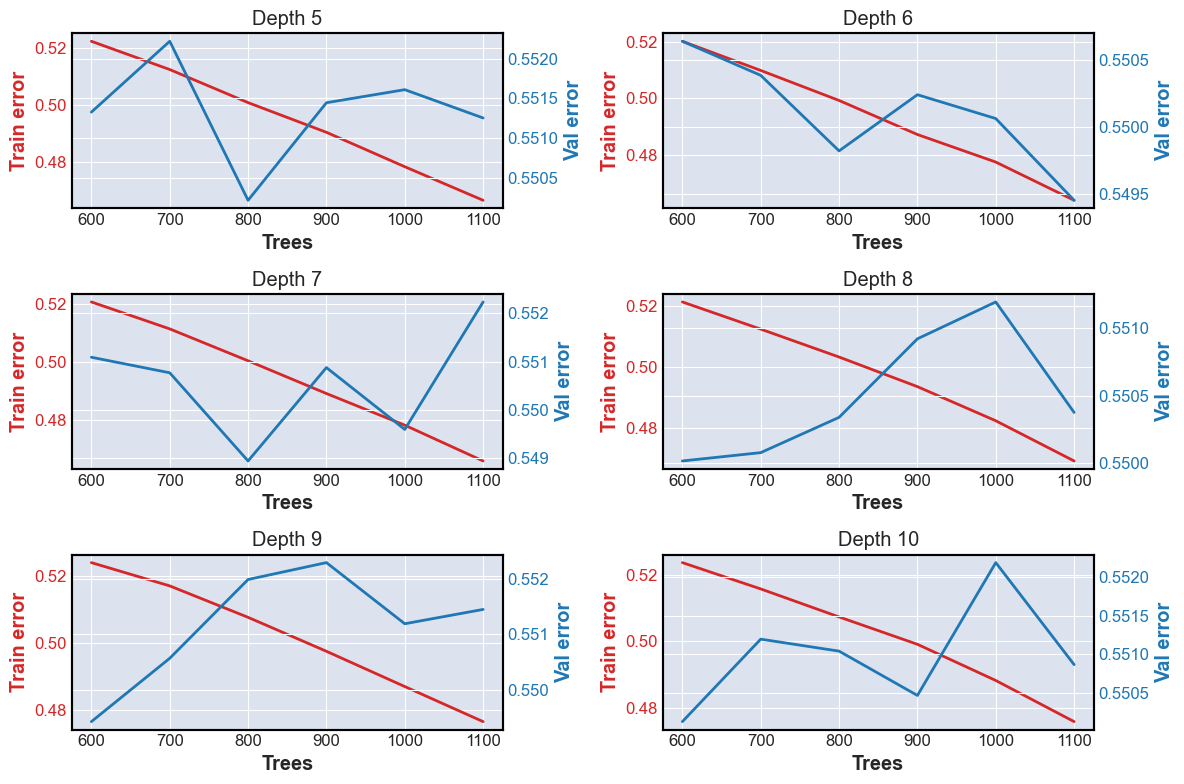

In [233]:
axes_columns_num = 2
# depth = range(8, 14)
# trees = range(800, 1500, 100)
depth = range(5, 11)
trees = range(600, 1200, 100)
# depth = range(4, 9)
# trees = range(200, 600, 100)

fig, axes = plt.subplots(ncols=axes_columns_num, nrows=math.ceil(len(depth)/axes_columns_num), figsize=(12, 8))

for i, d in enumerate(depth):
    quals_train = []
    quals_val = []

    for t in trees:
        q_train, q_val = train(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, n_estimators=t, max_depth=d)

        quals_train.append(1 - q_train)
        quals_val.append(1 - q_val)

    print_train_curve(axes[i//axes_columns_num][i%axes_columns_num], f'Depth {d}', 'Trees', trees, quals_train, quals_val)

fig.tight_layout()
plt.show()

In [165]:
clf = fit_classifier(X_train=X_train, y_train=y_train, n_estimators=1000, max_depth=9)

y_val_pred = clf.predict(X_val)
q_val = precision_score(y_true=y_val, y_pred=y_val_pred)

print(q_val)

0.46311475409836067


In [261]:
print(classification_report(y_true=y_val, y_pred=y_val_pred))

              precision    recall  f1-score   support

           0       0.84      0.48      0.61      6944
           1       0.41      0.79      0.54      3112

    accuracy                           0.58     10056
   macro avg       0.62      0.64      0.57     10056
weighted avg       0.70      0.58      0.59     10056



## Кластеризация

In [266]:
processed_data_with_pred = pd.concat([processed_data, pd.DataFrame(y_val_pred, columns=[PRED_CLASS_LABLE_KEY], index=X_val.index)], axis=1)
processed_data_with_pred[PRED_CLASS_LABLE_KEY] = processed_data_with_pred[PRED_CLASS_LABLE_KEY].fillna(0).astype(np.byte)
processed_data_with_pred.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67038 entries, 0 to 73725
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   class               67038 non-null  int64  
 1   t1_dweek            67038 non-null  int64  
 2   t2_dweek            67038 non-null  int64  
 3   t3_dweek            67038 non-null  int64  
 4   t4_dweek            67038 non-null  int64  
 5   t5_dweek            67038 non-null  int64  
 6   t1_direction        67038 non-null  int8   
 7   t1_part_body        67038 non-null  float64
 8   t1_head_body        67038 non-null  float64
 9   t1_tail_body        67038 non-null  float64
 10  t1_ma5_position     67038 non-null  int64  
 11  t1_ma10_position    67038 non-null  int64  
 12  t1_ma15_position    67038 non-null  int64  
 13  t2_ratio_size       67038 non-null  float64
 14  t2_ratio_body_size  67038 non-null  float64
 15  t2_ratio_close      67038 non-null  float64
 16  t2_direct

In [267]:
processed_data_only_pred_true = processed_data_with_pred[processed_data_with_pred[PRED_CLASS_LABLE_KEY] == 1]
processed_data_only_pred_true.head()

,class,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_direction,t1_part_body,t1_head_body,t1_tail_body,...,t5_ratio_body_size,t5_ratio_close,t5_direction,t5_part_body,t5_head_body,t5_tail_body,t5_ma5_position,t5_ma10_position,t5_ma15_position,pred_class
0,0,0,1,1,2,2,1,0.346154,0.576923,0.076923,...,0.517241,0.994722,0,0.527273,0.090909,0.381818,2,2,2,1
13,0,2,3,3,4,4,0,0.342105,0.184211,0.473684,...,0.285714,1.007433,1,0.677419,0.306452,0.016129,2,4,4,1
20,0,0,1,1,2,2,1,0.407407,0.037037,0.555556,...,0.592593,1.004589,1,0.540000,0.380000,0.080000,3,3,4,1
62,0,0,1,1,2,2,1,0.538462,0.307692,0.153846,...,1.261905,0.992448,0,0.560000,0.053333,0.386667,2,1,1,1
64,1,1,2,2,3,3,0,0.127660,0.659574,0.212766,...,2.764706,0.996554,0,0.293103,0.206897,0.500000,4,4,4,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Так как в задаче не предполается тестовый набор праметры масштабирования выучиваются на всём датасете
scaler.fit(processed_data.drop([CLASS_LABEL_KEY], axis=1))
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)

X_val_scaled.describe()

,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_direction,t1_part_body,t1_head_body,t1_tail_body,t1_ma5_position,...,t5_ratio_size,t5_ratio_body_size,t5_ratio_close,t5_direction,t5_part_body,t5_head_body,t5_tail_body,t5_ma5_position,t5_ma10_position,t5_ma15_position
count,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,...,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000,10056.000000
mean,0.444053,0.448449,0.425895,0.420346,0.496097,0.506961,0.436559,0.277890,0.285352,0.490752,...,0.029713,0.015787,0.613425,0.500895,0.437380,0.280036,0.282087,0.498981,0.498111,0.495202
std,0.330352,0.333198,0.318296,0.319167,0.356186,0.499976,0.249201,0.196378,0.198984,0.337048,...,0.029793,0.040718,0.018993,0.500024,0.249826,0.196186,0.199362,0.336648,0.410011,0.433474
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.243792,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.200000,0.200000,0.200000,0.250000,0.000000,0.228571,0.120000,0.125000,0.250000,...,0.014326,0.001634,0.604241,0.000000,0.228916,0.122807,0.120000,0.250000,0.000000,0.000000
50%,0.400000,0.400000,0.400000,0.400000,0.500000,1.000000,0.437500,0.241379,0.250000,0.500000,...,0.021967,0.004568,0.613509,1.000000,0.437500,0.244898,0.249204,0.500000,0.500000,0.500000
75%,0.800000,0.800000,0.600000,0.600000,0.750000,1.000000,0.636364,0.400000,0.416667,0.750000,...,0.034506,0.012745,0.622508,1.000000,0.634146,0.406250,0.411765,0.750000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.975000,1.000000,...,0.622222,0.759804,0.766816,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [271]:
X_val_scaled_with_pred = X_val_scaled.copy()
X_val_scaled_with_pred = pd.concat([X_val_scaled_with_pred, y_val], axis=1)
X_val_scaled_with_pred[PRED_CLASS_LABLE_KEY] = y_val_pred
X_val_scaled_with_pred.head()

,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_direction,t1_part_body,t1_head_body,t1_tail_body,t1_ma5_position,...,t5_ratio_close,t5_direction,t5_part_body,t5_head_body,t5_tail_body,t5_ma5_position,t5_ma10_position,t5_ma15_position,class,pred_class
68804,0.2,0.2,0.4,0.4,0.75,1.0,0.122807,0.526316,0.350877,0.75,...,0.626091,1.0,0.578947,0.315789,0.105263,0.0,0.0,0.0,0,1
38904,0.4,0.4,0.6,0.6,1.00,0.0,0.532468,0.298701,0.168831,1.00,...,0.568148,0.0,0.773684,0.042105,0.184211,0.5,1.0,1.0,0,1
2934,0.0,0.0,0.2,0.2,0.50,1.0,0.391304,0.521739,0.086957,1.00,...,0.627625,1.0,0.567568,0.378378,0.054054,0.0,0.0,0.0,0,1
3047,0.2,0.4,0.4,0.6,0.75,1.0,0.319149,0.531915,0.148936,0.50,...,0.581459,0.0,0.764706,0.161765,0.073529,0.5,0.5,0.5,0,1
17092,0.8,1.0,0.0,0.0,0.25,0.0,0.810345,0.172414,0.017241,0.50,...,0.624044,1.0,0.536585,0.219512,0.243902,0.5,1.0,1.0,0,1


In [273]:
# X_val_scaled_is_class_true = X_val_scaled_with_pred[X_val_scaled_with_pred['class'] == 1]
# y_val_scaled_pred_class = X_val_scaled_is_class_true['class_pred']
# X_val_scaled_is_class_true = X_val_scaled_is_class_true.drop(['class', 'class_pred'], axis=1)

X_val_scaled_is_pred_true = X_val_scaled_with_pred[X_val_scaled_with_pred[PRED_CLASS_LABLE_KEY] == 1]
y_val_scaled_class = X_val_scaled_is_pred_true[CLASS_LABEL_KEY]
X_val_scaled_is_pred_true = X_val_scaled_is_pred_true.drop([CLASS_LABEL_KEY, PRED_CLASS_LABLE_KEY], axis=1)
X_val_scaled_is_pred_true.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6095 entries, 68804 to 7650
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   t1_dweek            6095 non-null   float64
 1   t2_dweek            6095 non-null   float64
 2   t3_dweek            6095 non-null   float64
 3   t4_dweek            6095 non-null   float64
 4   t5_dweek            6095 non-null   float64
 5   t1_direction        6095 non-null   float64
 6   t1_part_body        6095 non-null   float64
 7   t1_head_body        6095 non-null   float64
 8   t1_tail_body        6095 non-null   float64
 9   t1_ma5_position     6095 non-null   float64
 10  t1_ma10_position    6095 non-null   float64
 11  t1_ma15_position    6095 non-null   float64
 12  t2_ratio_size       6095 non-null   float64
 13  t2_ratio_body_size  6095 non-null   float64
 14  t2_ratio_close      6095 non-null   float64
 15  t2_direction        6095 non-null   float64
 16  t2_part

d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid

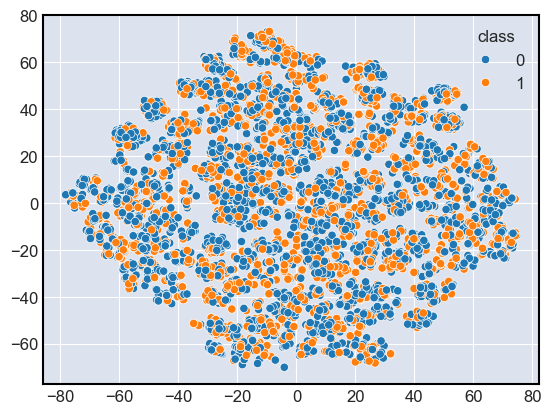

In [274]:
tsne = TSNE(n_components=2, random_state=10)

train_tsne = tsne.fit_transform(X_val_scaled_is_pred_true)

g = sns.scatterplot(x=train_tsne[:,0], y=train_tsne[:,1], hue=y_val_scaled_class)

In [275]:
from sklearn.cluster import KMeans

MIN_CLUSTER_COUNT = 1
MAX_CLUSTER_COUNT = 15

# Расчет инерции
inertia = []
inertia_iterations = range(MIN_CLUSTER_COUNT, MAX_CLUSTER_COUNT + 1)
for i in inertia_iterations:
    kmeans = KMeans(n_clusters=i, random_state=10).fit(X_val_scaled_is_pred_true)
    inertia_i = kmeans.inertia_
    inertia.append(inertia_i)

# Расчет переломного момента
D = []
D_iterations = range(MIN_CLUSTER_COUNT, MAX_CLUSTER_COUNT - 1)
for i in D_iterations:
    Di = (inertia[i] - inertia[i+1])/(inertia[i-1] - inertia[i])
    D.append(Di)

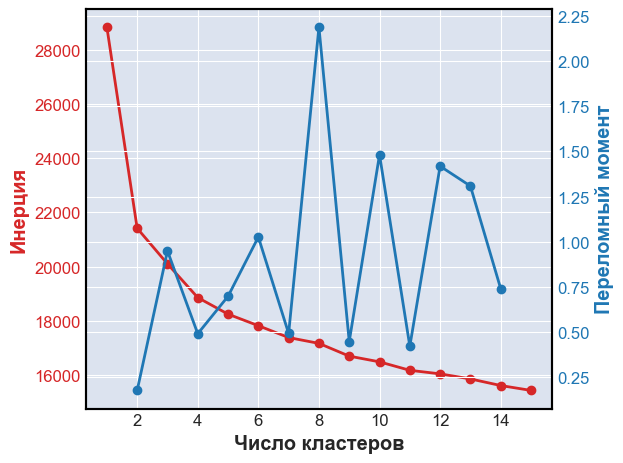

In [276]:
fig, ax1 = plt.subplots()

# Общая шкала аргумента
ax1.set_xlabel('Число кластеров')

# Совмещение графиков
ax2 = ax1.twinx()

# График инерции
color = 'tab:red'
ax1.set_ylabel('Инерция', color=color)
ax1.plot(inertia_iterations, inertia, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

# График переломного момента
color = 'tab:blue'
ax2.set_ylabel('Переломный момент', color=color)
# Для переломного момента индекс для числа кластеров смещается на 1
D_num_clusters = np.array(D_iterations) + 1
ax2.plot(D_num_clusters, D, color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()

In [277]:
labels = KMeans(n_clusters=11, random_state=10).fit(X_val_scaled_is_pred_true).labels_

In [ ]:
X_val['label'] = labels
processed_data[['class','label']].groupby('label').agg(['count', 'sum', 'mean'])

ValueError: Length of values (6095) does not match length of index (67038)

# Проверка тестового результата

In [167]:
y_test_pred = clf.predict(X_test)
q_test = precision_score(y_true=y_test, y_pred=y_test_pred)

print(q_test)

0.452


In [168]:
data_with_pred = pd.concat([data, pd.DataFrame(y_test_pred, columns=['pred_class'], index=X_test.index)], axis=1)
data_with_pred['pred_class'] = data_with_pred['pred_class'].fillna(0).astype(np.byte)
data_with_pred.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t5_ma15,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10,t6_ma15,class,pred_class
count,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,...,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000
mean,0.786559,0.789422,0.783634,0.786575,0.786537,0.786489,0.786439,0.786578,0.789442,0.783653,...,0.786516,0.786655,0.789518,0.783729,0.786671,0.786633,0.786584,0.786536,0.079672,0.021580
std,0.140805,0.141193,0.140353,0.140770,0.140757,0.140751,0.140746,0.140788,0.141176,0.140336,...,0.140678,0.140719,0.141107,0.140268,0.140684,0.140672,0.140666,0.140661,0.270796,0.145313
min,0.480700,0.485300,0.477300,0.480700,0.484080,0.486340,0.488300,0.480700,0.485300,0.477300,...,0.488300,0.480700,0.485300,0.477300,0.480700,0.484080,0.486340,0.488300,0.000000,0.000000
25%,0.709100,0.711600,0.706400,0.709000,0.709200,0.709510,0.709673,0.709100,0.711600,0.706400,...,0.709693,0.709200,0.711700,0.706500,0.709200,0.709280,0.709620,0.709707,0.000000,0.000000
50%,0.763900,0.766600,0.761200,0.764000,0.763780,0.763800,0.763693,0.763900,0.766600,0.761200,...,0.763733,0.763900,0.766700,0.761300,0.764000,0.763800,0.763850,0.763760,0.000000,0.000000
75%,0.894200,0.897800,0.891000,0.894100,0.894540,0.894880,0.895180,0.894200,0.897800,0.891000,...,0.895180,0.894200,0.897800,0.891000,0.894100,0.894540,0.894880,0.895180,0.000000,0.000000
max,1.104800,1.107800,1.101000,1.104700,1.100680,1.099970,1.095267,1.104800,1.107800,1.101000,...,1.095267,1.104800,1.107800,1.101000,1.104700,1.100680,1.099970,1.095267,1.000000,1.000000


In [169]:
data_only_pred_true = data_with_pred[data_with_pred['pred_class'] == 1]
data_only_pred_true.head()

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_dtime,...,t6_dtime,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10,t6_ma15,class,pred_class
25,AUD,2001-02-22 00:00:00,0.5252,0.5283,0.5228,0.5250,0.52548,0.52672,0.527847,2001-02-22 12:00:00,...,2001-02-26 00:00:00,0.5244,0.5273,0.5244,0.5265,0.52410,0.52479,0.525847,1,1
61,AUD,2001-03-19 00:00:00,0.4941,0.4970,0.4920,0.4967,0.49448,0.49822,0.501887,2001-03-19 12:00:00,...,2001-03-21 12:00:00,0.5036,0.5040,0.4965,0.4994,0.50012,0.49730,0.498853,0,1
94,AUD,2001-04-10 12:00:00,0.4933,0.4970,0.4915,0.4948,0.49386,0.49092,0.488847,2001-04-11 00:00:00,...,2001-04-13 00:00:00,0.5070,0.5105,0.5061,0.5092,0.50344,0.49865,0.495093,1,1
148,AUD,2001-05-15 00:00:00,0.5175,0.5195,0.5164,0.5182,0.52018,0.52113,0.520407,2001-05-15 12:00:00,...,2001-05-17 12:00:00,0.5244,0.5285,0.5237,0.5284,0.52276,0.52147,0.521673,1,1
173,AUD,2001-05-30 12:00:00,0.5187,0.5205,0.5110,0.5130,0.51724,0.51793,0.519100,2001-05-31 00:00:00,...,2001-06-02 00:00:00,0.5086,0.5098,0.5062,0.5082,0.50840,0.51282,0.514753,0,1


In [ ]:
for idx in data_only_pred_true.index:
    print_combination(data_only_pred_true.loc[idx], output_folder='pred_data')

In [170]:
data_class_or_pred_true = data_with_pred[(data_with_pred['pred_class'] == 1) | (data_with_pred['class'] == 1)]
data_class_or_pred_true.head()

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_dtime,...,t6_dtime,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10,t6_ma15,class,pred_class
25,AUD,2001-02-22 00:00:00,0.5252,0.5283,0.5228,0.5250,0.52548,0.52672,0.527847,2001-02-22 12:00:00,...,2001-02-26 00:00:00,0.5244,0.5273,0.5244,0.5265,0.52410,0.52479,0.525847,1,1
28,AUD,2001-02-23 12:00:00,0.5235,0.5238,0.5206,0.5224,0.52354,0.52527,0.525640,2001-02-24 00:00:00,...,2001-02-28 00:00:00,0.5250,0.5262,0.5223,0.5254,0.52502,0.52428,0.525187,1,0
57,AUD,2001-03-15 12:00:00,0.4951,0.4962,0.4923,0.4937,0.49898,0.50391,0.506460,2001-03-16 00:00:00,...,2001-03-19 12:00:00,0.4966,0.5043,0.4952,0.5015,0.49604,0.49751,0.501287,1,0
61,AUD,2001-03-19 00:00:00,0.4941,0.4970,0.4920,0.4967,0.49448,0.49822,0.501887,2001-03-19 12:00:00,...,2001-03-21 12:00:00,0.5036,0.5040,0.4965,0.4994,0.50012,0.49730,0.498853,0,1
91,AUD,2001-04-06 12:00:00,0.4923,0.4938,0.4901,0.4916,0.49002,0.48754,0.488300,2001-04-07 00:00:00,...,2001-04-11 12:00:00,0.4975,0.5035,0.4953,0.5004,0.49670,0.49336,0.490593,1,0


In [172]:
profit = data_only_pred_true[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] - data_only_pred_true[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]
profit.sum() * 1000
# profit

np.float64(-16.69999999999949)

In [188]:
data_test_pred_class = pd.concat([pd.DataFrame(y_test_pred, columns=['pred_class'], index=X_test.index), y_test], axis=1)
data_test_pred_class

,pred_class,class
3275,0,0
11192,0,0
1161,0,0
6503,0,0
1551,1,0
...,...,...
6004,0,0
1616,0,0
7997,0,0
9247,0,0


In [208]:
data_test = pd.concat([X_test, data_test_pred_class], axis=1)
data_test = data_test[(data_test['class'] + data_test['pred_class']) > 0]
data_test

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t4_part_body,t4_head_body,t4_tail_body,t5_ratio_size,t5_is_white,t5_part_body,t5_head_body,t5_tail_body,pred_class,class
1551,0.574970,0.867178,0.486423,0.592680,0.288076,0.149055,0.000000,0.610390,0.698937,0.468713,...,0.250000,0.275000,0.475000,0.952381,1,0.595238,0.357143,0.047619,1,0
11483,0.851852,0.901235,0.518519,0.703704,0.656790,0.434568,0.869959,0.691358,1.000000,0.197531,...,0.111111,0.250000,0.638889,0.720000,0,0.400000,0.440000,0.160000,1,0
3100,0.193182,0.284091,0.000000,0.261364,0.186364,0.018182,0.031818,0.238636,0.556818,0.193182,...,0.477273,0.136364,0.386364,0.676923,1,0.676923,0.200000,0.123077,1,1
4036,0.108374,0.487685,0.073892,0.443350,0.000000,0.053695,0.091954,0.443350,0.729064,0.300493,...,0.831325,0.024096,0.144578,1.012195,0,0.182927,0.585366,0.231707,0,1
1295,0.321739,0.556522,0.052174,0.452174,0.187826,0.480870,0.633043,0.452174,0.452174,0.104348,...,0.642857,0.300000,0.057143,1.794872,1,0.461538,0.410256,0.128205,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10982,0.609375,0.945312,0.179688,0.945312,0.792188,0.614063,0.439063,0.921875,1.000000,0.328125,...,0.693182,0.102273,0.204545,1.466667,0,0.600000,0.233333,0.166667,0,1
4611,0.422368,0.450020,0.281032,0.320975,0.303769,0.153523,0.000000,0.317902,0.385498,0.231872,...,0.697674,0.069767,0.232558,0.170635,1,0.726190,0.138889,0.134921,0,1
9095,0.684026,0.815682,0.245173,0.297835,0.464599,0.291691,0.000000,0.315389,0.868344,0.157402,...,0.492958,0.338028,0.169014,1.868421,1,0.578947,0.263158,0.157895,0,1
921,0.260870,0.413043,0.021739,0.130435,0.030435,0.130435,0.179710,0.195652,0.456522,0.000000,...,0.428571,0.142857,0.428571,0.750000,0,0.285714,0.214286,0.500000,0,1


In [209]:
data_true = data_test[data_test['class'] == 1]
data_true

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t4_part_body,t4_head_body,t4_tail_body,t5_ratio_size,t5_is_white,t5_part_body,t5_head_body,t5_tail_body,pred_class,class
3100,0.193182,0.284091,0.000000,0.261364,0.186364,0.018182,0.031818,0.238636,0.556818,0.193182,...,0.477273,0.136364,0.386364,0.676923,1,0.676923,0.200000,0.123077,1,1
4036,0.108374,0.487685,0.073892,0.443350,0.000000,0.053695,0.091954,0.443350,0.729064,0.300493,...,0.831325,0.024096,0.144578,1.012195,0,0.182927,0.585366,0.231707,0,1
1295,0.321739,0.556522,0.052174,0.452174,0.187826,0.480870,0.633043,0.452174,0.452174,0.104348,...,0.642857,0.300000,0.057143,1.794872,1,0.461538,0.410256,0.128205,0,1
9551,0.311688,0.389610,0.233766,0.324675,0.659740,0.648052,0.601732,0.337662,0.545455,0.155844,...,0.673077,0.288462,0.038462,1.529412,0,0.029412,0.176471,0.794118,0,1
2121,0.967742,1.000000,0.830645,0.911290,0.627419,0.194355,0.000000,0.919355,0.927419,0.604839,...,0.083333,0.500000,0.416667,0.610169,1,0.457627,0.389831,0.152542,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10982,0.609375,0.945312,0.179688,0.945312,0.792188,0.614063,0.439063,0.921875,1.000000,0.328125,...,0.693182,0.102273,0.204545,1.466667,0,0.600000,0.233333,0.166667,0,1
4611,0.422368,0.450020,0.281032,0.320975,0.303769,0.153523,0.000000,0.317902,0.385498,0.231872,...,0.697674,0.069767,0.232558,0.170635,1,0.726190,0.138889,0.134921,0,1
9095,0.684026,0.815682,0.245173,0.297835,0.464599,0.291691,0.000000,0.315389,0.868344,0.157402,...,0.492958,0.338028,0.169014,1.868421,1,0.578947,0.263158,0.157895,0,1
921,0.260870,0.413043,0.021739,0.130435,0.030435,0.130435,0.179710,0.195652,0.456522,0.000000,...,0.428571,0.142857,0.428571,0.750000,0,0.285714,0.214286,0.500000,0,1


In [ ]:
data.loc[49021]

currency                    GBP
t1_dtime    2006-05-22 00:00:00
t1_open                  1.8764
t1_high                  1.8783
t1_low                   1.8758
t1_close                 1.8762
t1_ma5                  1.88202
t1_ma10                 1.88329
t1_ma15                1.885907
t2_dtime    2006-05-22 12:00:00
t2_open                   1.876
t2_high                  1.8777
t2_low                   1.8631
t2_close                 1.8751
t2_ma5                  1.88016
t2_ma10                 1.88303
t2_ma15                 1.88528
t3_dtime    2006-05-23 00:00:00
t3_open                  1.8753
t3_high                  1.8886
t3_low                   1.8733
t3_close                 1.8847
t3_ma5                   1.8782
t3_ma10                  1.8834
t3_ma15                 1.88462
t4_dtime    2006-05-23 12:00:00
t4_open                  1.8848
t4_high                  1.8883
t4_low                   1.8793
t4_close                 1.8843
t4_ma5                  1.87996
t4_ma10 

In [ ]:
data_test.iloc[49021]

KeyError: 49021

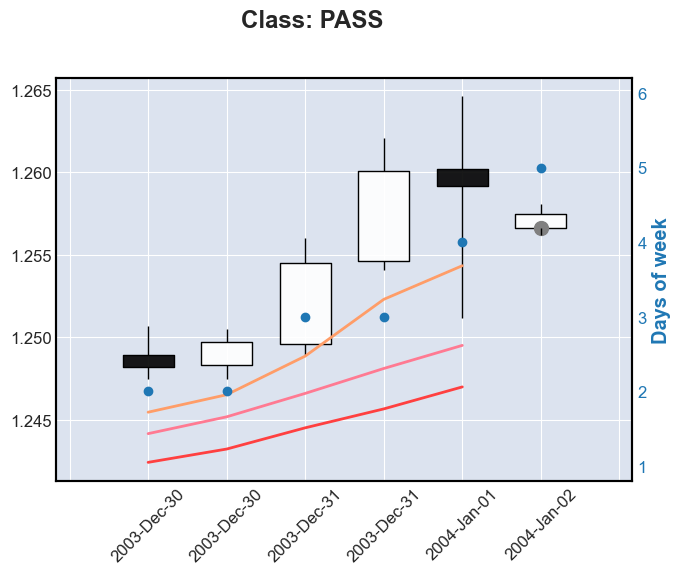

In [ ]:
print_combination(data.iloc[36553])

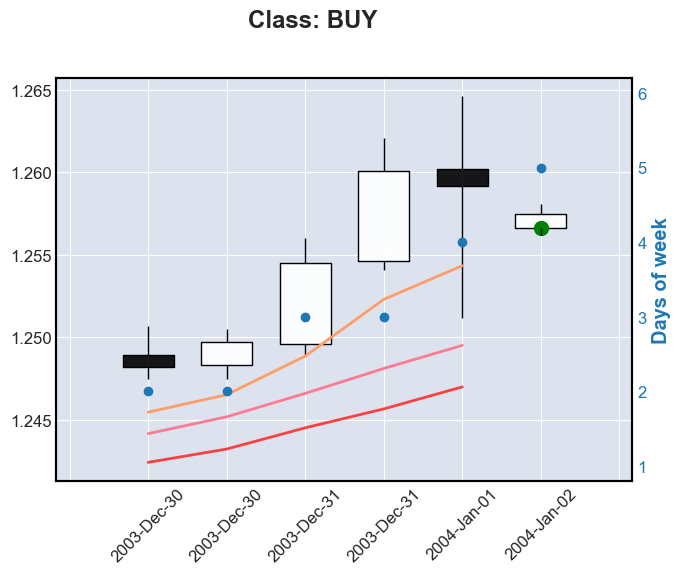

In [ ]:
print_combination(data_test.loc[36553])

In [ ]:
print_combination(X_test.iloc[1])

KeyError: "None of [Index(['t6_open', 't6_high', 't6_low', 't6_close', 't6_ma5', 't6_ma10',\n       't6_ma15'],\n      dtype='object')] are in the [index]"

In [ ]:
pd.Timestamp(datetime.now() + timedelta(days=1))

Timestamp('2026-04-14 15:27:31.280293')

In [196]:
X_val.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t4_ratio_size,t4_is_white,t4_part_body,t4_head_body,t4_tail_body,t5_ratio_size,t5_is_white,t5_part_body,t5_head_body,t5_tail_body
count,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,...,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000
mean,0.506507,0.704075,0.303364,0.508114,0.499444,0.481846,0.466796,0.508573,0.717675,0.307713,...,inf,0.497123,0.435896,0.271797,0.291731,inf,0.490219,0.443592,0.274906,0.280352
std,0.269757,0.233849,0.243583,0.230101,0.253325,0.310399,0.385560,0.231194,0.213248,0.220358,...,NaN,0.500136,0.241810,0.188642,0.196460,NaN,0.500048,0.249123,0.194333,0.197135
min,0.000000,0.011799,0.000000,0.006061,0.000000,0.000000,0.000000,0.012121,0.132812,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288298,0.514858,0.067447,0.323306,0.299252,0.208068,0.038384,0.320000,0.557844,0.117220,...,0.680213,0.000000,0.238095,0.125000,0.135865,0.661417,0.000000,0.240000,0.120000,0.124170
50%,0.507022,0.723858,0.286299,0.506961,0.497765,0.451232,0.424567,0.508055,0.742919,0.292450,...,1.024100,0.000000,0.433333,0.233688,0.262398,0.987422,0.000000,0.447088,0.240000,0.241225
75%,0.730686,0.922331,0.500000,0.693741,0.696321,0.775065,0.874985,0.687939,0.899079,0.478540,...,1.500000,1.000000,0.625000,0.391641,0.418506,1.459178,1.000000,0.644391,0.397600,0.405405
max,1.000000,1.000000,0.925532,0.976471,1.000000,1.000000,1.000000,1.000000,1.000000,0.910448,...,inf,1.000000,1.000000,0.971014,0.928571,inf,1.000000,1.000000,0.904762,0.919614


In [210]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Так как в задаче не предполается тестовый набор праметры масштабирования выучиваются на всём датасете
scaler.fit(X_val)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
# X_val_scaled = scaler.transform(X_val)

X_val_scaled.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t4_ratio_size,t4_is_white,t4_part_body,t4_head_body,t4_tail_body,t5_ratio_size,t5_is_white,t5_part_body,t5_head_body,t5_tail_body
count,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,...,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000,1738.000000
mean,0.506507,0.700542,0.327772,0.517362,0.499444,0.481846,0.466796,0.502544,0.674436,0.337980,...,0.099577,0.497123,0.435896,0.279911,0.314172,0.143680,0.490219,0.443592,0.303843,0.304858
std,0.269757,0.236641,0.263181,0.237117,0.253325,0.310399,0.385560,0.234030,0.245908,0.242033,...,0.074260,0.500136,0.241810,0.194274,0.211572,0.101621,0.500048,0.249123,0.214789,0.214367
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288298,0.509065,0.072873,0.326919,0.299252,0.208068,0.038384,0.311656,0.490127,0.128750,...,0.054278,0.000000,0.238095,0.128731,0.146317,0.080056,0.000000,0.240000,0.132632,0.135024
50%,0.507022,0.720560,0.309334,0.516174,0.497765,0.451232,0.424567,0.502019,0.703546,0.321216,...,0.081905,0.000000,0.433333,0.240664,0.282582,0.119353,0.000000,0.447088,0.265263,0.262312
75%,0.730686,0.921404,0.540230,0.708650,0.696321,0.775065,0.874985,0.684110,0.883622,0.525609,...,0.119851,1.000000,0.625000,0.403331,0.450698,0.176545,1.000000,0.644391,0.439453,0.440843
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [211]:
y_val_pred.sum()

np.int64(225)

In [212]:
y_val.sum()

np.int64(374)

In [ ]:
103.45 - 90.9

12.549999999999997

In [ ]:
(y_val * y_val_pred.squeeze()).count()

np.int64(11059)

In [ ]:
y_val_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(11059,))

In [ ]:
y_val

3084     0
2220     0
66616    0
48177    0
53687    0
        ..
33032    0
22680    0
29680    1
21299    0
18407    0
Name: class, Length: 11059, dtype: int64

In [ ]:
len(y_val)

11059

In [ ]:
X_val

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t2_is_white,t3_is_white,t4_is_white,t5_is_white
3084,0.423529,1.000000,0.400000,0.623529,0.498824,0.309412,0.611765,0.929412,0.505882,0.552941,...,3,4,4,5,0,1,0,0,1,0
2220,0.000000,0.335570,0.000000,0.290828,0.519016,1.000000,0.302013,0.458613,0.100671,0.391499,...,0,0,1,1,2,1,1,1,1,1
66616,0.573034,0.685393,0.235955,0.505618,0.370787,0.379775,0.516854,1.000000,0.393258,0.797753,...,1,1,2,2,3,0,1,0,0,1
48177,0.092820,0.364273,0.000000,0.357268,0.143608,0.069527,0.355517,0.462347,0.327496,0.394046,...,1,2,2,3,3,1,1,1,1,1
53687,0.773131,0.887199,0.481622,0.570342,0.712294,1.000000,0.583016,0.633714,0.304183,0.468948,...,0,1,1,2,2,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33032,0.698630,0.808219,0.607306,0.698630,0.490411,0.000000,0.716895,0.936073,0.607306,0.908676,...,4,5,0,0,1,0,1,1,1,0
22680,0.824818,1.000000,0.700730,0.744526,0.702190,0.559854,0.729927,0.795620,0.445255,0.510949,...,2,2,3,3,4,0,0,0,1,1
29680,0.484848,0.787879,0.128788,0.765152,0.601515,0.848485,0.765152,1.000000,0.416667,0.446970,...,3,4,4,5,0,1,0,1,0,0
21299,0.523256,0.843023,0.517442,0.598837,0.641860,0.536047,0.604651,0.674419,0.505814,0.656977,...,1,1,2,2,3,1,1,0,0,0


In [ ]:
X_val_scaled

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t2_is_white,t3_is_white,t4_is_white,t5_is_white
3084,0.423529,1.000000,0.407143,0.622811,0.498824,0.309412,0.611765,0.924610,0.515080,0.552941,...,0.6,0.8,0.8,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2220,0.000000,0.312855,0.000000,0.289474,0.519016,1.000000,0.302013,0.421784,0.102502,0.391499,...,0.0,0.0,0.2,0.2,0.4,1.0,1.0,1.0,1.0,1.0
66616,0.573034,0.674637,0.240169,0.504675,0.370787,0.379775,0.516854,1.000000,0.400409,0.797753,...,0.2,0.2,0.4,0.4,0.6,0.0,1.0,0.0,0.0,1.0
48177,0.092820,0.342539,0.000000,0.356041,0.143608,0.069527,0.355517,0.425772,0.333450,0.394046,...,0.2,0.4,0.4,0.6,0.6,1.0,1.0,1.0,1.0,1.0
53687,0.773131,0.883343,0.490223,0.569522,0.712294,1.000000,0.583016,0.608796,0.309713,0.468948,...,0.0,0.2,0.2,0.4,0.4,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33032,0.698630,0.801663,0.618151,0.698055,0.490411,0.000000,0.716895,0.931724,0.618348,0.908676,...,0.8,1.0,0.0,0.0,0.2,0.0,1.0,1.0,1.0,0.0
22680,0.824818,1.000000,0.713243,0.744038,0.702190,0.559854,0.729927,0.781717,0.453351,0.510949,...,0.4,0.4,0.6,0.6,0.8,0.0,0.0,0.0,1.0,1.0
29680,0.484848,0.780627,0.131088,0.764703,0.601515,0.848485,0.765152,1.000000,0.424242,0.446970,...,0.6,0.8,0.8,1.0,0.0,1.0,0.0,1.0,0.0,0.0
21299,0.523256,0.837657,0.526682,0.598072,0.641860,0.536047,0.604651,0.652270,0.515011,0.656977,...,0.2,0.2,0.4,0.4,0.6,1.0,1.0,0.0,0.0,0.0


In [213]:
X_val_scaled_with_pred = X_val_scaled.copy()
X_val_scaled_with_pred = pd.concat([X_val_scaled_with_pred, y_val], axis=1)
X_val_scaled_with_pred['class_pred'] = y_val_pred

In [214]:
y_val_pred.sum()

np.int64(225)

In [215]:
X_val_scaled_is_class_true = X_val_scaled_with_pred[X_val_scaled_with_pred['class'] == 1]
y_val_scaled_pred_class = X_val_scaled_is_class_true['class_pred']
X_val_scaled_is_class_true = X_val_scaled_is_class_true.drop(['class', 'class_pred'], axis=1)

In [ ]:
X_val_scaled_is_class_true

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t5_low,t5_close,t5_ma5,t5_ma10,t5_ma15,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek
70001,0.421429,0.606716,0.142083,0.235714,0.661429,0.662143,0.521429,0.228571,0.397813,0.000000,...,0.526270,0.528571,0.436726,0.667530,0.639470,0.6,0.6,0.8,0.8,1.0
36627,0.213759,0.197593,0.063021,0.072482,0.423833,0.249386,0.000000,0.078624,0.296746,0.023766,...,0.574112,0.877150,0.448895,0.542849,0.313975,0.0,0.0,0.2,0.2,0.4
54614,0.521127,0.866950,0.394440,0.785211,0.475352,0.138380,0.000000,0.764085,0.791104,0.752881,...,0.744931,0.771127,0.776376,0.573725,0.240120,1.0,0.0,0.0,0.2,0.2
68864,0.201681,0.228856,0.000000,0.067227,0.196639,0.125210,0.070028,0.075630,0.256560,0.051337,...,0.831418,0.890756,0.456758,0.375220,0.201538,0.6,0.8,0.8,1.0,0.0
9115,0.124138,0.322457,0.079422,0.193103,0.067586,0.022069,0.063908,0.179310,0.296552,0.000000,...,0.725889,0.724138,0.435928,0.218796,0.128068,0.4,0.4,0.6,0.6,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23189,0.331950,0.543073,0.112946,0.431535,0.585062,0.994072,0.994072,0.435685,0.542214,0.092946,...,0.681312,0.917012,0.547832,0.805136,0.879105,0.6,0.6,0.8,0.8,1.0
41956,0.438959,0.505748,0.426664,0.474865,0.501795,0.206463,0.000000,0.474865,0.584234,0.369251,...,0.646263,0.968582,0.716729,0.590211,0.297468,0.0,0.0,0.2,0.2,0.4
63805,0.088889,0.364234,0.000000,0.355556,0.331111,0.505556,0.533333,0.377778,0.560544,0.192323,...,0.725083,0.977778,0.655300,0.514733,0.572042,0.4,0.4,0.6,0.6,0.8
48945,0.299728,0.261635,0.000000,0.106267,0.329700,0.382016,0.413987,0.103542,0.432798,0.047164,...,0.742800,0.722071,0.512336,0.482762,0.462576,0.0,0.2,0.2,0.4,0.4


d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid

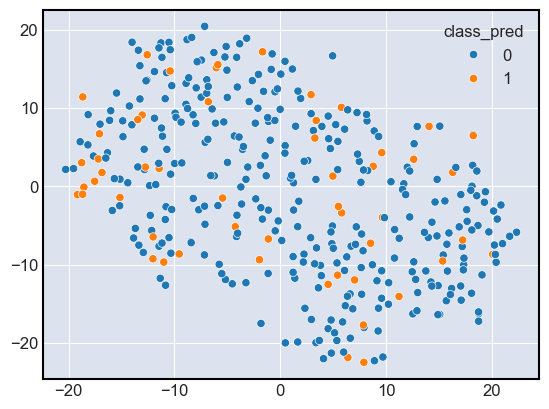

In [216]:
tsne = TSNE(n_components=2, random_state=10)

train_tsne = tsne.fit_transform(X_val_scaled_is_class_true)

g = sns.scatterplot(x=train_tsne[:,0], y=train_tsne[:,1], hue=y_val_scaled_pred_class)

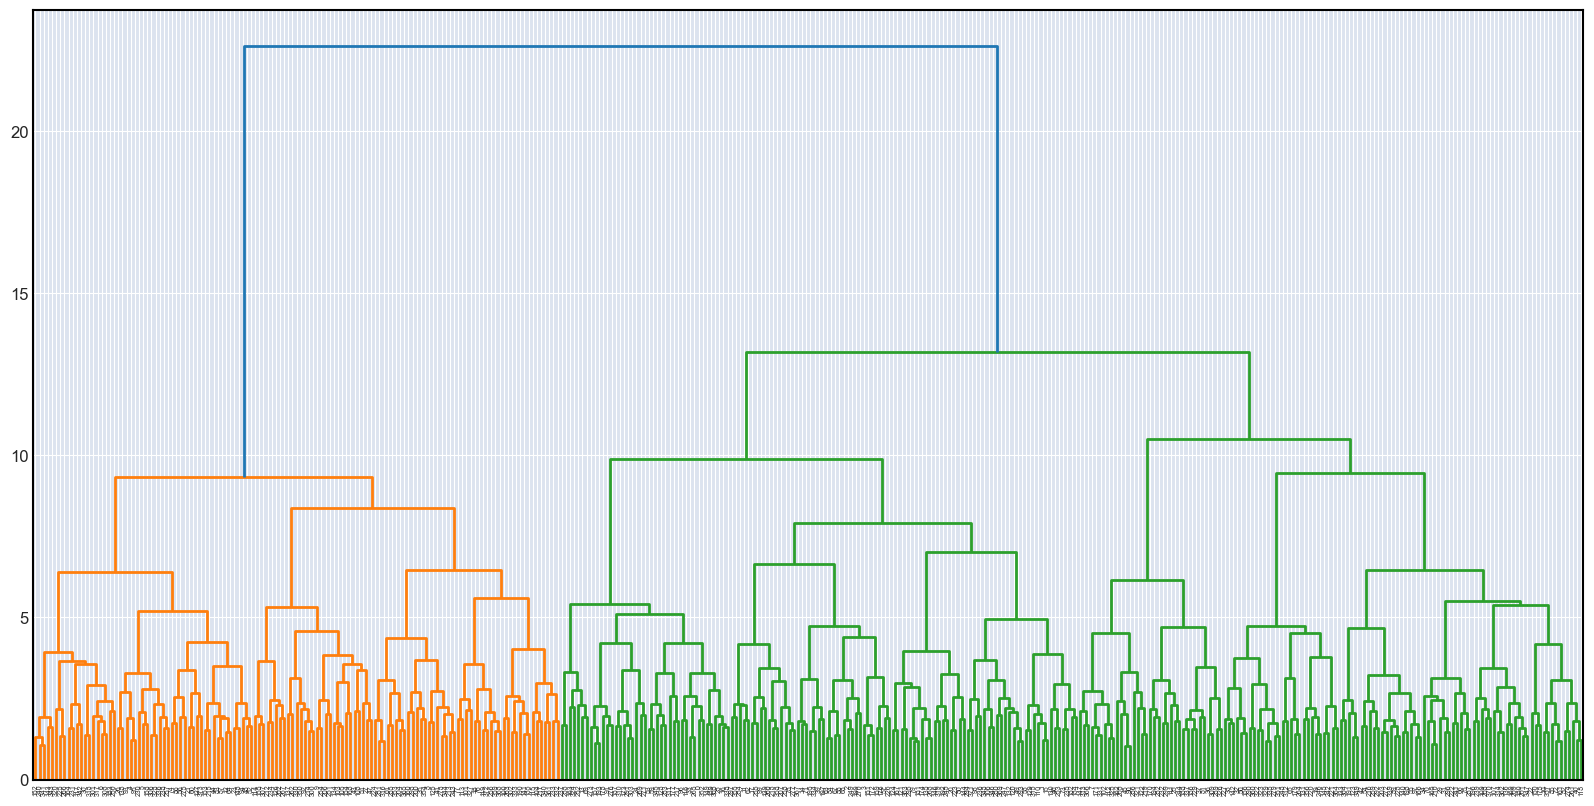

In [217]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(20,10))
linkage_ = linkage(X_val_scaled_is_class_true, method='ward')
dendrogram_ = dendrogram(linkage_)


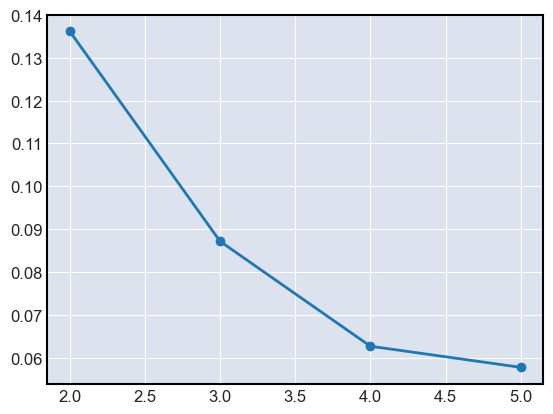

In [218]:
silhouette = []
clasters = range(2,6)
for i in clasters:
    agg = AgglomerativeClustering(n_clusters=i).fit(X_val_scaled_is_class_true)
    labels = agg.labels_
    score = silhouette_score(X_val_scaled_is_class_true, labels)
    silhouette.append(score)

plt.plot(clasters, silhouette, marker='o');

In [219]:
agg = AgglomerativeClustering(n_clusters=4).fit(X_val_scaled_is_class_true)
labels = agg.labels_

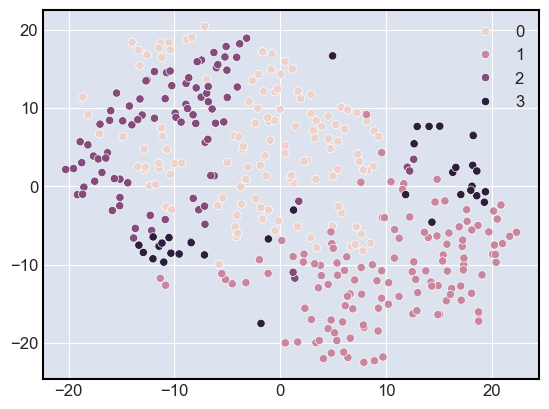

In [220]:
tsne = TSNE(n_components=2, random_state=10)

train_tsne = tsne.fit_transform(X_val_scaled_is_class_true)

g = sns.scatterplot(x=train_tsne[:,0], y=train_tsne[:,1], hue=labels)

In [221]:
X_val_scaled_is_class_true['labels'] = labels
X_val_scaled_is_class_true['class_pred'] = y_val_scaled_pred_class

X_val_scaled_is_class_true

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t4_part_body,t4_head_body,t4_tail_body,t5_ratio_size,t5_is_white,t5_part_body,t5_head_body,t5_tail_body,labels,class_pred
3756,0.637838,0.841372,0.665797,0.795868,0.622703,0.345405,0.201081,0.770187,0.756903,0.754010,...,0.700000,0.030896,0.290769,0.161616,1.0,0.053333,0.088421,0.942424,0,0
9617,0.644914,0.679520,0.634589,0.638554,0.742802,0.326296,0.000000,0.611413,0.867199,0.613480,...,0.483871,0.166105,0.382134,0.091648,0.0,0.731707,0.107831,0.185656,0,0
2203,0.746399,1.000000,0.684675,0.753235,0.658109,0.241077,0.000000,0.724272,0.870027,0.025447,...,0.656250,0.273554,0.084135,0.337286,1.0,0.391304,0.624714,0.047279,0,0
3222,0.613636,0.770014,0.442006,0.485580,0.481818,0.615909,0.748485,0.470859,1.000000,0.374441,...,0.588235,0.121159,0.316742,0.098124,0.0,0.809524,0.052632,0.155345,0,0
2292,0.822581,1.000000,0.313682,0.359413,0.780645,0.645161,0.535484,0.338759,0.702412,0.363168,...,0.387755,0.441365,0.197802,0.077135,1.0,0.636364,0.287081,0.112978,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159,0.986726,1.000000,0.693215,0.805381,0.729204,0.214159,0.000000,0.811879,0.816312,0.354780,...,0.375000,0.418377,0.235577,0.088154,0.0,0.295455,0.527512,0.247139,0,0
9343,0.115756,0.463118,0.055586,0.162742,0.025723,0.025723,0.265809,0.137455,0.555053,0.109483,...,0.575758,0.249661,0.195804,0.097561,1.0,0.170732,0.673941,0.238700,2,0
3064,0.476117,0.859669,0.481129,0.754318,0.064715,0.000000,0.037494,0.742643,0.920043,0.709111,...,0.020000,0.494328,0.538462,0.242424,0.0,0.200000,0.132632,0.739441,0,0
7836,0.804919,0.883194,0.720206,0.827537,0.745388,0.899245,1.000000,0.815256,0.833054,0.271674,...,0.413333,0.233433,0.387692,0.133690,0.0,0.735294,0.146285,0.143922,1,0


In [222]:
X_val_scaled_is_class_true[['class_pred','labels']].groupby('labels').agg(['count', 'sum', 'mean'])

class_pred              
            count sum      mean
labels                         
0             125  17  0.136000
1             127  13  0.102362
2              87  15  0.172414
3              35   8  0.228571

In [223]:
X_val_scaled_is_class_true['class_pred'].agg(['count', 'sum', 'mean'])

count    374.000000
sum       53.000000
mean       0.141711
Name: class_pred, dtype: float64

In [225]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Так как в задаче не предполается тестовый набор праметры масштабирования выучиваются на всём датасете
scaler.fit(processed_data)
processed_data_scaled = pd.DataFrame(scaler.transform(processed_data), columns=processed_data.columns, index=processed_data.index)
# X_val_scaled = scaler.transform(X_val)

processed_data_scaled.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t4_ratio_size,t4_is_white,t4_part_body,t4_head_body,t4_tail_body,t5_ratio_size,t5_is_white,t5_part_body,t5_head_body,t5_tail_body
count,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,...,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000,11585.000000
mean,0.500293,0.703841,0.305380,0.506949,0.495264,0.483002,0.471835,0.506499,0.692754,0.312469,...,0.048082,0.504359,0.437068,0.277086,0.284465,0.048080,0.504273,0.437098,0.277058,0.284463
std,0.265773,0.234543,0.244537,0.231140,0.250800,0.312420,0.387719,0.231099,0.226430,0.223697,...,0.039246,0.500003,0.248561,0.194070,0.198022,0.039247,0.500003,0.248578,0.194083,0.198022
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.283951,0.517405,0.072704,0.322235,0.301014,0.200000,0.041778,0.320513,0.523052,0.121739,...,0.026144,0.000000,0.230769,0.120000,0.125000,0.026144,0.000000,0.230769,0.120000,0.125000
50%,0.500000,0.720000,0.288014,0.507177,0.488688,0.465766,0.445967,0.506897,0.712635,0.297770,...,0.039216,1.000000,0.437500,0.242424,0.250000,0.039216,1.000000,0.437500,0.242424,0.250000
75%,0.716400,0.926471,0.501099,0.694444,0.688372,0.773151,0.878652,0.692655,0.887568,0.485950,...,0.057890,1.000000,0.633929,0.400000,0.411765,0.057890,1.000000,0.634146,0.400000,0.411765
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


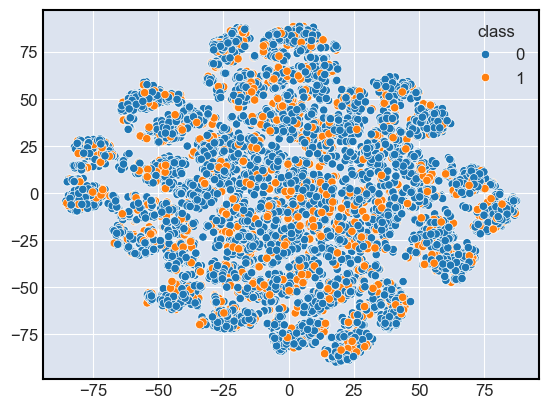

In [226]:
tsne = TSNE(n_components=2, random_state=10)

processed_data_scaled = processed_data_scaled.drop(['class'], axis=1)
processed_data_tsne = tsne.fit_transform(processed_data_scaled)

g = sns.scatterplot(x=processed_data_tsne[:,0], y=processed_data_tsne[:,1], hue=processed_data['class'])

In [227]:
from sklearn.cluster import KMeans

MIN_CLUSTER_COUNT = 1
MAX_CLUSTER_COUNT = 15

# Расчет инерции
inertia = []
inertia_iterations = range(MIN_CLUSTER_COUNT, MAX_CLUSTER_COUNT + 1)
for i in inertia_iterations:
    kmeans = KMeans(n_clusters=i, random_state=10).fit(processed_data_scaled)
    inertia_i = kmeans.inertia_
    inertia.append(inertia_i)

# Расчет переломного момента
D = []
D_iterations = range(MIN_CLUSTER_COUNT, MAX_CLUSTER_COUNT - 1)
for i in D_iterations:
    Di = (inertia[i] - inertia[i+1])/(inertia[i-1] - inertia[i])
    D.append(Di)

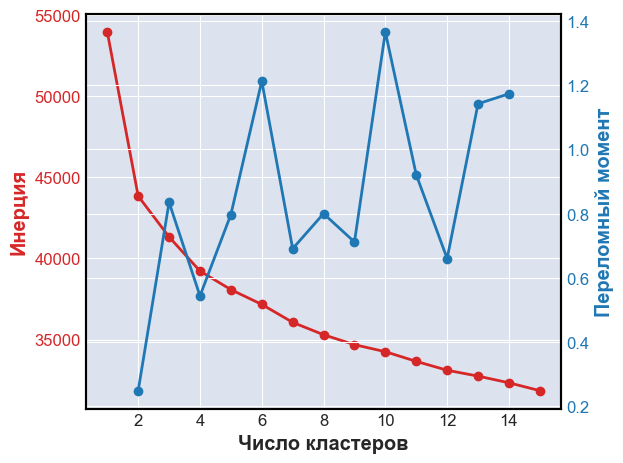

In [228]:
fig, ax1 = plt.subplots()

# Общая шкала аргумента
ax1.set_xlabel('Число кластеров')

# Совмещение графиков
ax2 = ax1.twinx()

# График инерции
color = 'tab:red'
ax1.set_ylabel('Инерция', color=color)
ax1.plot(inertia_iterations, inertia, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

# График переломного момента
color = 'tab:blue'
ax2.set_ylabel('Переломный момент', color=color)
# Для переломного момента индекс для числа кластеров смещается на 1
D_num_clusters = np.array(D_iterations) + 1
ax2.plot(D_num_clusters, D, color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()

In [229]:
labels = KMeans(n_clusters=12, random_state=10).fit(processed_data_scaled).labels_

In [230]:
processed_data['label'] = labels
processed_data[['class','label']].groupby('label').agg(['count', 'sum', 'mean'])

class               
      count  sum      mean
label                     
0       802  171  0.213217
1       976  216  0.221311
2      1151  257  0.223284
3      1169  272  0.232678
4       952  206  0.216387
5       797  195  0.244668
6      1002  203  0.202595
7      1099  226  0.205641
8       949  193  0.203372
9       735  147  0.200000
10      971  193  0.198764
11      982  217  0.220978

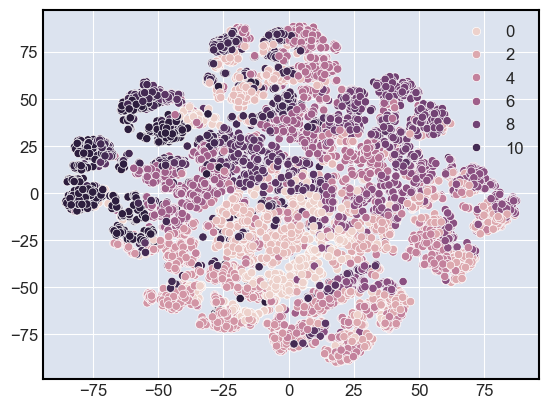

In [231]:
g = sns.scatterplot(x=processed_data_tsne[:,0], y=processed_data_tsne[:,1], hue=labels)

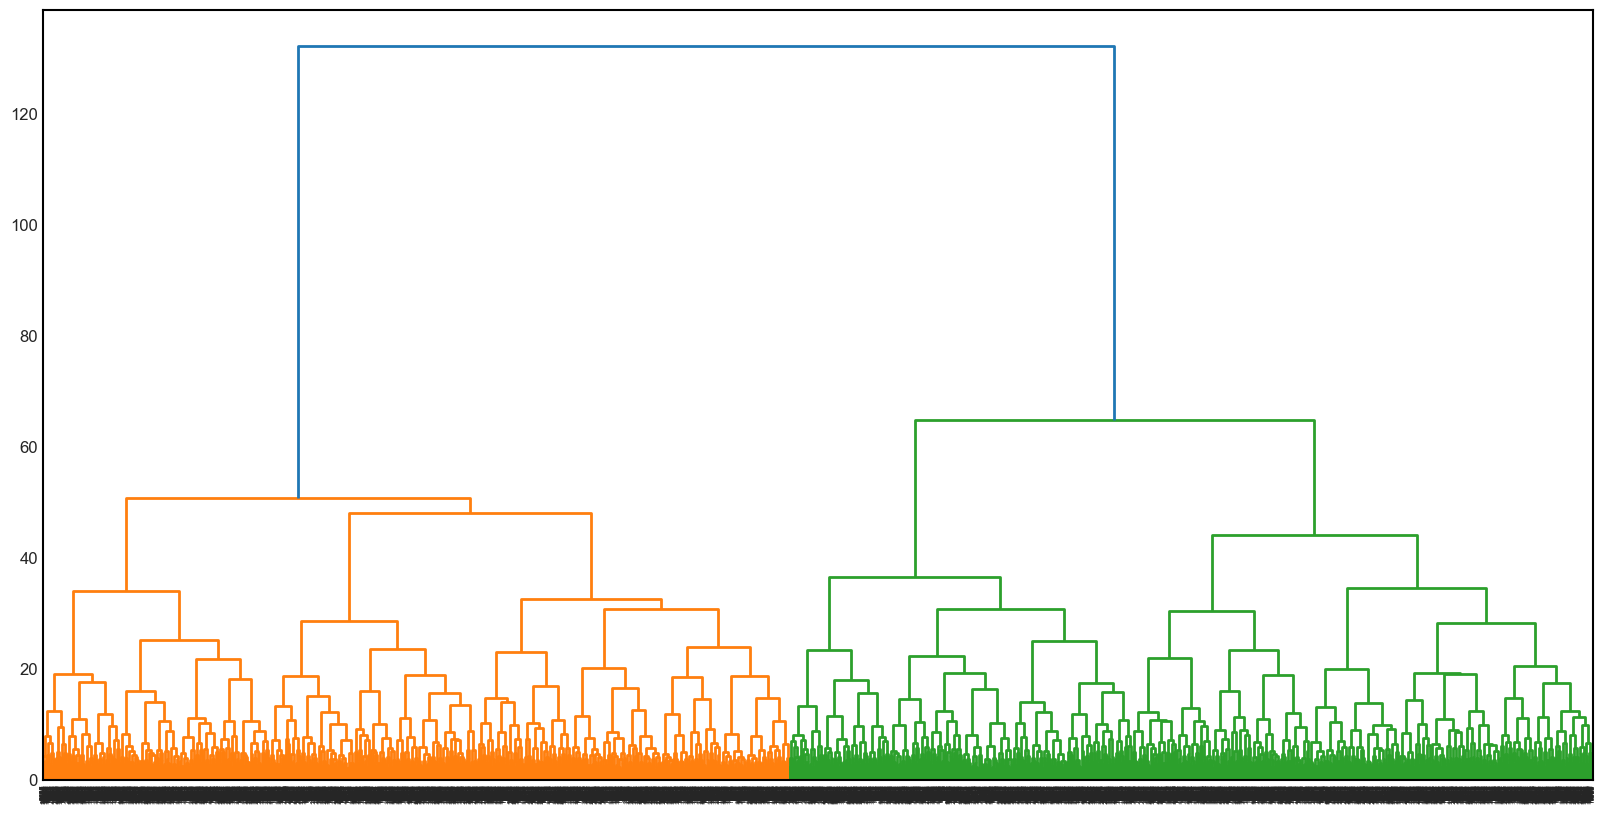

In [232]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(20,10))
linkage_ = linkage(processed_data_scaled, method='ward')
dendrogram_ = dendrogram(linkage_)

In [89]:
processed_data_scaled

,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t1_part_body,t1_head_body,t1_tail_body,t1_ma5_position,...,t4_head_body,t4_tail_body,t4_ma5_position,t4_ma10_position,t5_is_white,t5_part_body,t5_head_body,t5_tail_body,t5_ma5_position,t5_ma10_position
0,0.0,0.2,0.2,0.4,0.4,1.0,0.3,0.5,0.0,0.75,...,0.3,0.2,0.75,0.75,0.0,0.5,0.0,0.3,0.50,0.50
1,0.2,0.2,0.4,0.4,0.6,0.0,0.4,0.1,0.4,0.50,...,0.0,0.3,0.50,0.50,1.0,0.1,0.2,0.6,1.00,1.00
2,0.2,0.4,0.4,0.6,0.6,0.0,0.4,0.3,0.1,0.75,...,0.2,0.6,1.00,1.00,0.0,0.8,0.0,0.1,1.00,1.00
3,0.4,0.4,0.6,0.6,0.8,1.0,0.4,0.3,0.2,0.75,...,0.0,0.1,1.00,1.00,0.0,0.4,0.0,0.4,1.00,1.00
4,0.4,0.6,0.6,0.8,0.8,0.0,0.5,0.0,0.3,0.50,...,0.0,0.4,1.00,1.00,0.0,0.2,0.0,0.6,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73721,0.0,0.0,0.2,0.2,0.4,0.0,0.6,0.2,0.1,1.00,...,0.3,0.1,0.25,0.50,0.0,0.4,0.3,0.2,0.50,0.75
73722,0.0,0.2,0.2,0.4,0.4,1.0,0.5,0.0,0.3,0.50,...,0.3,0.2,0.50,0.75,0.0,0.3,0.3,0.2,0.75,0.75
73723,0.2,0.2,0.4,0.4,0.6,1.0,0.6,0.2,0.0,0.00,...,0.3,0.2,0.75,0.75,1.0,0.1,0.7,0.1,0.75,0.75
73724,0.2,0.4,0.4,0.6,0.6,0.0,0.5,0.3,0.1,0.25,...,0.7,0.1,0.75,0.75,0.0,0.5,0.3,0.1,0.75,1.00


In [88]:
silhouette = []
clasters = range(5,14)
for i in clasters:
    agg = AgglomerativeClustering(n_clusters=i).fit(processed_data_scaled)
    labels = agg.labels_
    score = silhouette_score(processed_data_scaled, labels)
    silhouette.append(score)

plt.plot(clasters, silhouette, marker='o');

MemoryError: Unable to allocate 20.2 GiB for an array with shape (2717724675,) and data type float64